<a href="https://colab.research.google.com/github/abduzcan369/simulador-mundial-2026/blob/main/MUNDIAL_RANDOM_FOREST_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Predicción del Mundial 2026: Un Análisis Basado en Datos y Machine Learning

Este proyecto académico tiene como objetivo la predicción de los resultados de la Copa Mundial de Fútbol de 2026, así como la identificación de los equipos con mayor probabilidad de alcanzar las etapas finales del torneo, utilizando una metodología basada en el análisis de datos y la aplicación de modelos de *Machine Learning*.

El estudio se estructura en varias fases, comenzando por la recopilación y preprocesamiento de datos históricos y actuales de equipos de fútbol. Posteriormente, se desarrollan dos modelos de *Random Forest*: uno de regresión para estimar la "fuerza" general de un equipo y predecir posibles campeones, y otro de clasificación para pronosticar el resultado de partidos individuales (victoria, empate o derrota). Finalmente, se simula el torneo completo, desde la fase de grupos hasta la final, incorporando resultados reales disponibles para mejorar la precisión y proporcionar un panorama completo de los posibles resultados.

El presente documento detalla el proceso implementado, los modelos utilizados y los resultados obtenidos, presentados en un formato adecuado para una evaluación académica.

In [24]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, accuracy_score

# =============================================================================
# CARGAR DATASETS
# ===================================================

try:
    elo_df = pd.read_csv("eloratings.csv")
    wc_history_df = pd.read_csv("fifa_world_cup_history.csv")
    fifa_rankings_df = pd.read_csv("fifa_world_rankings_jan_2026.csv")
    mundial_dataset_df = pd.read_csv("mundial2026_dataset.csv")
    former_names_df = pd.read_csv("former_names.csv")
    results_df = pd.read_csv("results.csv")
    print("Todos los archivos CSV necesarios cargados exitosamente.")
except FileNotFoundError as e:
    print(f"Error: Archivo no encontrado - {e}.")
except Exception as e:
    print(f"Ocurrió un error: {e}")

print("Preparando los datos para la predicción del Mundial 2026...")

Todos los archivos CSV necesarios cargados exitosamente.
Preparando los datos para la predicción del Mundial 2026...


### 1. Carga de Librerías y Conjuntos de Datos Iniciales

En esta primera etapa, se procede a la importación de las librerías necesarias para el análisis y modelado de datos, incluyendo `pandas` para la manipulación de DataFrames, `numpy` para operaciones numéricas, `matplotlib` y `seaborn` para la visualización, y módulos de `scikit-learn` para el preprocesamiento y los modelos de *Random Forest*. Adicionalmente, se cargan múltiples conjuntos de datos en formato CSV que contienen información relevante como el sistema de puntuación ELO, historial de Copas del Mundo, rankings FIFA, datos de equipos para el Mundial 2026 y resultados históricos de partidos.

### 2. Carga de Datos de las Fases del Torneo

Para estructurar la simulación del Mundial, se cargan archivos de texto que definen la composición de los grupos y el formato de los 16avos de final. Estos archivos (`fase_de_grupos.txt` y `16_avos.txt`) proporcionan la base para la progresión de los equipos a lo largo del campeonato.

In [25]:
# Cargar datos de la fase de grupos
fase_de_grupos_df = pd.read_csv('fase_de_grupos.txt')

print("DataFrame 'fase_de_grupos_df' cargado:")
display(fase_de_grupos_df.head())

DataFrame 'fase_de_grupos_df' cargado:


,Grupo,Equipo_1,Equipo_2,Equipo_3,Equipo_4
0,A,México,Corea del Sur,República Checa,Sudáfrica
1,B,Canadá,Suiza,Bosnia y Herzegovina,Catar
2,C,Brasil,Marruecos,Escocia,Haití
3,D,Estados Unidos,Australia,Paraguay,Turquía
4,E,Alemania,Costa de Marfil,Ecuador,Curazao


In [26]:
# Cargar datos de los 16avos de final
_16_avos_df = pd.read_csv('16_avos.txt')

print("DataFrame '_16_avos_df' cargado:")
display(_16_avos_df.head())

DataFrame '_16_avos_df' cargado:


,Partido,Local_Fase_Grupos,Visitante_Fase_Grupos
0,1,1A,Mejor_3_C/E/F/H/I
1,2,1B,Mejor_3_E/F/G/I/J
2,3,1C,2F
3,4,1D,Mejor_3_B/E/F/I/J
4,5,1E,Mejor_3_A/B/C/D/F


In [27]:
# Nueva lógica de bracket basada estrictamente en el orden visual (16 bloques)
bracket_logic = [
    {'Fase': 'Octavos', 'Partido_ID': 17, 'Local_Viene_De': 'Ganador_5', 'Visitante_Viene_De': 'Ganador_9'},
    {'Fase': 'Octavos', 'Partido_ID': 18, 'Local_Viene_De': 'Ganador_13', 'Visitante_Viene_De': 'Ganador_6'},
    {'Fase': 'Octavos', 'Partido_ID': 19, 'Local_Viene_De': 'Ganador_16', 'Visitante_Viene_De': 'Ganador_8'},
    {'Fase': 'Octavos', 'Partido_ID': 20, 'Local_Viene_De': 'Ganador_4', 'Visitante_Viene_De': 'Ganador_7'},
    {'Fase': 'Octavos', 'Partido_ID': 21, 'Local_Viene_De': 'Ganador_3', 'Visitante_Viene_De': 'Ganador_15'},
    {'Fase': 'Octavos', 'Partido_ID': 22, 'Local_Viene_De': 'Ganador_1', 'Visitante_Viene_De': 'Ganador_12'},
    {'Fase': 'Octavos', 'Partido_ID': 23, 'Local_Viene_De': 'Ganador_10', 'Visitante_Viene_De': 'Ganador_14'},
    {'Fase': 'Octavos', 'Partido_ID': 24, 'Local_Viene_De': 'Ganador_2', 'Visitante_Viene_De': 'Ganador_11'},
    {'Fase': 'Cuartos', 'Partido_ID': 25, 'Local_Viene_De': 'Ganador_17', 'Visitante_Viene_De': 'Ganador_18'},
    {'Fase': 'Cuartos', 'Partido_ID': 26, 'Local_Viene_De': 'Ganador_19', 'Visitante_Viene_De': 'Ganador_20'},
    {'Fase': 'Cuartos', 'Partido_ID': 27, 'Local_Viene_De': 'Ganador_21', 'Visitante_Viene_De': 'Ganador_22'},
    {'Fase': 'Cuartos', 'Partido_ID': 28, 'Local_Viene_De': 'Ganador_23', 'Visitante_Viene_De': 'Ganador_24'},
    {'Fase': 'Semifinal', 'Partido_ID': 29, 'Local_Viene_De': 'Ganador_25', 'Visitante_Viene_De': 'Ganador_26'},
    {'Fase': 'Semifinal', 'Partido_ID': 30, 'Local_Viene_De': 'Ganador_27', 'Visitante_Viene_De': 'Ganador_28'},
    {'Fase': 'Tercer_Puesto', 'Partido_ID': 31, 'Local_Viene_De': 'Perdedor_29', 'Visitante_Viene_De': 'Perdedor_30'},
    {'Fase': 'Final', 'Partido_ID': 32, 'Local_Viene_De': 'Ganador_29', 'Visitante_Viene_De': 'Ganador_30'}
]

fases_finales_2026_df = pd.DataFrame(bracket_logic)
display(fases_finales_2026_df)

,Fase,Partido_ID,Local_Viene_De,Visitante_Viene_De
0,Octavos,17,Ganador_5,Ganador_9
1,Octavos,18,Ganador_13,Ganador_6
2,Octavos,19,Ganador_16,Ganador_8
3,Octavos,20,Ganador_4,Ganador_7
4,Octavos,21,Ganador_3,Ganador_15
5,Octavos,22,Ganador_1,Ganador_12
6,Octavos,23,Ganador_10,Ganador_14
7,Octavos,24,Ganador_2,Ganador_11
8,Cuartos,25,Ganador_17,Ganador_18
9,Cuartos,26,Ganador_19,Ganador_20


### 3. Definición de la Estructura del Cuadro Final (Bracket)

Se establece el esquema de las fases eliminatorias del torneo (Octavos, Cuartos, Semifinales, Tercer Puesto y Final) mediante un DataFrame `fases_finales_2026_df`. Esta estructura es crucial para determinar cómo los ganadores de cada partido avanzan en el campeonato y cómo se emparejan los encuentros subsiguientes.

In [28]:
fase_de_grupos_actualizado_df = pd.read_csv('fase_de_grupos_actualizado.txt')

# Limpiar nombres de equipos en el DataFrame de resultados actualizados
fase_de_grupos_actualizado_df['Equipo_Local_Clean'] = fase_de_grupos_actualizado_df['Equipo_Local'].apply(lambda x: map_team_names(pd.Series([x.replace('_', ' ')])).iloc[0].upper().strip())
fase_de_grupos_actualizado_df['Equipo_Visitante_Clean'] = fase_de_grupos_actualizado_df['Equipo_Visitante'].apply(lambda x: map_team_names(pd.Series([x.replace('_', ' ')])).iloc[0].upper().strip())

print("DataFrame 'fase_de_grupos_actualizado_df' cargado y nombres limpiados:")
display(fase_de_grupos_actualizado_df.head())

DataFrame 'fase_de_grupos_actualizado_df' cargado y nombres limpiados:


,Partido_ID,Grupo,Equipo_Local,Equipo_Visitante,Goles_Local,Goles_Visitante,Estado,Equipo_Local_Clean,Equipo_Visitante_Clean
0,1,A,México,Corea_del_Sur,1.0,0.0,Finalizado,MEXICO,SOUTH KOREA
1,2,A,México,República_Checa,3.0,0.0,Finalizado,MEXICO,CZECHIA
2,3,A,México,Sudáfrica,2.0,0.0,Finalizado,MEXICO,SOUTH AFRICA
3,4,A,Corea_del_Sur,República_Checa,2.0,1.0,Finalizado,SOUTH KOREA,CZECHIA
4,5,A,Corea_del_Sur,Sudáfrica,0.0,1.0,Finalizado,SOUTH KOREA,SOUTH AFRICA


### 4. Carga y Limpieza de Datos Actualizados de la Fase de Grupos

Se carga un archivo (`fase_de_grupos_actualizado.txt`) que puede contener resultados reales o proyecciones más recientes de los partidos de la fase de grupos. Se realiza una limpieza de los nombres de los equipos para asegurar la consistencia y facilitar el mapeo con otros conjuntos de datos, utilizando una función `map_team_names` que estandariza las denominaciones.

In [29]:
import pandas as pd
import numpy as np

# Usar los DataFrames ya cargados globalmente
elo_data = elo_df.copy()
fifa_rankings = fifa_rankings_df.copy()
mundial_data = mundial_dataset_df.copy()
wc_history = wc_history_df.copy()
former_names = former_names_df.copy()

elo_data['date'] = pd.to_datetime(elo_data['date'], format='mixed')
elo_latest = elo_data.loc[elo_data.groupby('team')['date'].idxmax()].copy()
elo_latest['team_clean'] = elo_latest['team'].str.replace('\u00a0', ' ', regex=True).str.upper().str.strip()
elo_latest = elo_latest[['team', 'rating', 'team_clean']]

# Diccionario corregido: Mapeo a NETHERLANDS por petición del usuario
translate_team_dict = {
    "Francia": "France", "Inglaterra": "England", "España": "Spain", "Portugal": "Portugal",
    "Alemania": "Germany", "Brasil": "Brazil", "Argentina": "Argentina", "Países Bajos": "NETHERLANDS",
    "Noruega": "Norway", "Bélgica": "Belgium", "Costa de Marfil": "Ivory Coast", "Senegal": "Senegal",
    "Turquía": "Turkey", "Marruecos": "Morocco", "Suecia": "Sweden", "Croacia": "Croatia",
    "Estados Unidos": "United States", "Ecuador": "Ecuador", "Uruguay": "Uruguay", "Suiza": "Switzerland",
    "Colombia": "Colombia", "Japón": "Japan", "Argelia": "Algeria", "Austria": "Austria",
    "Ghana": "Ghana", "Canadá": "Canada", "México": "Mexico", "República Checa": "Czechia",
    "Escocia": "Scotland", "Paraguay": "Paraguay", "Bosnia y Herzegovina": "Bosnia and Herzegovina",
    "Congo DR": "DR Congo", "Corea del Sur": "South Korea", "Egipto": "Egypt", "Uzbekistán": "Uzbekistan",
    "Australia": "Australia", "Túnez": "Tunisia", "Haití": "Haiti", "Cabo Verde": "Cape Verde",
    "Sudáfrica": "South Africa", "Arabia Saudí": "Saudi Arabia", "Panamá": "Panama",
    "Nueva Zelanda": "New Zealand", "Irán": "Iran", "Curazao": "Curaçao", "Iraq": "Iraq",
    "Jordania": "Jordan", "Qatar": "Qatar"
}

translate_team_df = pd.DataFrame(list(translate_team_dict.items()), columns=['equipo_esp', 'name_eng'])
mundial_data_clean = mundial_data.merge(translate_team_df, left_on='equipo', right_on='equipo_esp', how='left')

historical_map = pd.Series(former_names.current.values, index=former_names.former).to_dict()
manual_map = {
    "West Germany": "Germany", "Soviet Union": "Russia", "Czechoslovakia": "Czechia",
    "Yugoslavia": "Serbia", "USA": "United States", "South Korea": "South Korea",
    "England": "England", "Netherlands": "NETHERLANDS", "IR Iran": "Iran", "Holland": "NETHERLANDS"
}
all_maps = {**historical_map, **manual_map, **translate_team_dict}

def map_team_names(team_vector):
    return team_vector.map(lambda x: all_maps.get(x, x))

history_recent = wc_history[wc_history['Year'] >= 2010].copy()
history_recent_melted = history_recent.melt(
    id_vars=['Year', 'Host_Country'],
    value_vars=['Winner', 'Runner_Up', 'Third_Place', 'Fourth_Place'],
    var_name='Position',
    value_name='Team_old'
)
history_recent_melted['Team'] = map_team_names(history_recent_melted['Team_old'])

conditions = [
    history_recent_melted['Position'] == 'Winner',
    history_recent_melted['Position'] == 'Runner_Up',
    history_recent_melted['Position'] == 'Third_Place',
    history_recent_melted['Position'] == 'Fourth_Place'
]
choices = [5, 3, 2, 1]
history_recent_melted['Points'] = np.select(conditions, choices, default=0)

history_score = history_recent_melted.groupby('Team')['Points'].sum().reset_index()
history_score.rename(columns={'Points': 'History_Score'}, inplace=True)

mundial_data_clean['name_eng_upper'] = mundial_data_clean['name_eng'].str.upper()
candidates = mundial_data_clean.merge(elo_latest, left_on='name_eng_upper', right_on='team_clean', how='left')
candidates = candidates.merge(history_score, left_on='name_eng', right_on='Team', how='left')
candidates = candidates.merge(fifa_rankings, left_on='name_eng', right_on='Country', how='left')

candidates = candidates.drop(columns=['equipo_esp', 'team', 'team_clean', 'Team', 'Country', 'name_eng_upper'], errors='ignore')
candidates = candidates.rename(columns={'equipo': 'equipo_original'})

display(candidates.head())

,equipo_original,valor_total_mercado,valor_promedio_jugador,edad_promedio,valor_jugador_mas_valioso,jugadores_top5_ligas,jugadores_champions,dato_estimado,name_eng,rating,History_Score,Rank,Points,Confederation,World_Cup_Titles,Best_WC_Finish,Continental_Titles
0,Francia,1520.0,58.46,27.2,180.0,23,19,0,France,2062.0,8.0,3.0,1870.00,UEFA,2.0,Champions (2018),3.0
1,Inglaterra,1360.0,52.31,26.8,130.0,26,18,0,England,2042.0,1.0,4.0,1834.12,UEFA,1.0,Champions (1966),0.0
2,España,1220.0,46.92,25.6,200.0,22,17,0,Spain,2171.0,5.0,1.0,1877.18,UEFA,1.0,Champions (2010),12.0
3,Portugal,1010.0,38.85,28.1,140.0,20,16,0,Portugal,1976.0,NaN,6.0,1760.38,UEFA,0.0,3rd Place (1966),2.0
4,Alemania,947.0,36.42,25.9,100.0,21,16,0,Germany,1910.0,7.0,10.0,1724.15,UEFA,4.0,Champions (2014),3.0


### 5. Preprocesamiento de Datos y Creación de Variables para la Predicción de Campeones

Esta sección se centra en la preparación exhaustiva de los datos para la predicción de los candidatos a campeón del Mundial 2026. Se realizan las siguientes operaciones:

*   **Consolidación de ELO Ratings:** Se extraen los ratings ELO más recientes para cada equipo (`elo_latest`) y se estandarizan sus nombres.
*   **Mapeo de Nombres de Equipos:** Se define un diccionario `translate_team_dict` y `all_maps` para unificar los nombres de los equipos, manejando variaciones idiomáticas y nombres históricos. La función `map_team_names` aplica esta estandarización.
*   **Cálculo de Puntuación Histórica (`History_Score`):** Se analiza el desempeño de los equipos en las últimas Copas del Mundo (desde 2010), asignando puntos según la posición final (Ganador, Subcampeón, Tercero, Cuarto). Esto genera el `history_score`.
*   **Fusión de Datos:** Se combinan los DataFrames `mundial_data`, `elo_latest`, `history_score` y `fifa_rankings` para crear un conjunto de datos `candidates` unificado, que incluye variables como el rating ELO, el valor de mercado de la plantilla, el número de jugadores en Champions League y la puntuación histórica.

In [30]:
# =============================================================================
# PREDICCIÓN MUNDIAL 2026 - CÓDIGO EN PYTHON
# =============================================================================

# Las librerías necesarias (pandas, numpy, MinMaxScaler) ya han sido cargadas en la primera celda.

In [31]:
# 7. Rellenar valores faltantes (algunos equipos pequeños pueden no tener ELO o Historial)
# Asignamos la media del dataset para no penalizar excesivamente para 'rating', y 0 para 'History_Score'.

candidates['rating'] = candidates['rating'].fillna(candidates['rating'].mean())
candidates['History_Score'] = candidates['History_Score'].fillna(0)

# Asegurar que los valores numéricos estén en un tipo adecuado si no lo están ya
# La conversión en R a `as.numeric` es automática, en pandas ya suelen ser float/int
# Si fuera necesario, se harían aquí:
# candidates['valor_total_mercado'] = pd.to_numeric(candidates['valor_total_mercado'], errors='coerce')
# candidates['jugadores_champions'] = pd.to_numeric(candidates['jugadores_champions'], errors='coerce')

print("Valores nulos después de rellenar (primeras 5 filas):")
print(candidates[['rating', 'History_Score', 'valor_total_mercado', 'jugadores_champions']].head())

Valores nulos después de rellenar (primeras 5 filas):
   rating  History_Score  valor_total_mercado  jugadores_champions
0  2062.0            8.0               1520.0                   19
1  2042.0            1.0               1360.0                   18
2  2171.0            5.0               1220.0                   17
3  1976.0            0.0               1010.0                   16
4  1910.0            7.0                947.0                   16


### 6. Tratamiento de Valores Faltantes y Normalización de Características

Para garantizar la robustez del modelo, se abordan los valores faltantes en las características clave. Los `ratings` de ELO se rellenan con la media del conjunto de datos, mientras que `History_Score` se establece en 0 para equipos sin historial reciente. Posteriormente, las características numéricas (`rating`, `valor_total_mercado`, `jugadores_champions`, `History_Score`) se normalizan utilizando `MinMaxScaler` para escalarlas en un rango de 0 a 1, lo cual es fundamental para una combinación ponderada equitativa y para el correcto funcionamiento de algunos algoritmos de *Machine Learning*.

In [32]:
# 8. Normalizar las variables para crear un índice compuesto (0 a 1)
features_to_normalize = ['rating', 'valor_total_mercado', 'jugadores_champions', 'History_Score']
scaler = MinMaxScaler()

candidates_scaled = candidates.copy()
candidates_scaled[features_to_normalize] = scaler.fit_transform(candidates_scaled[features_to_normalize])

candidates_scaled = candidates_scaled.rename(columns={
    'rating': 'Elo_Norm',
    'valor_total_mercado': 'Valor_Norm',
    'jugadores_champions': 'Champions_Norm',
    'History_Score': 'History_Norm'
})

print("Variables normalizadas exitosamente.")

Variables normalizadas exitosamente.


In [33]:
# 9. Calcular puntuación final con pesos
# Pesos asignados:
# - Elo: 35% (mejor predictor histórico)
# - Valor de mercado: 25% (calidad de plantilla)
# - Jugadores en Champions: 15% (experiencia en alta presión)
# - Historial reciente: 25% (saber ganar / ADN de campeón)

candidates_final = candidates_scaled.copy()
candidates_final['Final_Score'] = (
    candidates_final['Elo_Norm'] * 0.35 +
    candidates_final['Valor_Norm'] * 0.25 +
    candidates_final['Champions_Norm'] * 0.15 +
    candidates_final['History_Norm'] * 0.25
)

candidates_final = candidates_final.sort_values(by='Final_Score', ascending=False)

print("Primeras 5 filas del dataframe candidates_final con la puntuación calculada:")
print(candidates_final[['equipo_original', 'Elo_Norm', 'Valor_Norm', 'Champions_Norm', 'History_Norm', 'Final_Score']].head())

Primeras 5 filas del dataframe candidates_final con la puntuación calculada:
  equipo_original  Elo_Norm  Valor_Norm  Champions_Norm  History_Norm  \
0         Francia  0.853495    1.000000        1.000000         1.000   
2          España  1.000000    0.800009        0.894737         0.625   
6       Argentina  0.922043    0.525022        0.631579         1.000   
4        Alemania  0.649194    0.618018        0.842105         0.875   
1      Inglaterra  0.826613    0.893338        0.947368         0.125   

   Final_Score  
0     0.948723  
2     0.840463  
6     0.798707  
4     0.726788  
1     0.686004  


### 7. Cálculo de la Puntuación Final y Determinación de Candidatos al Título

Se calcula una `Final_Score` para cada equipo combinando las características normalizadas (`Elo_Norm`, `Valor_Norm`, `Champions_Norm`, `History_Norm`) con pesos predefinidos que reflejan su importancia relativa en la determinación del éxito en un torneo como el Mundial. Los pesos asignados son:

*   **Elo (0.35):** Considerado un predictor histórico robusto del rendimiento.
*   **Valor de Mercado (0.25):** Refleja la calidad y profundidad de la plantilla.
*   **Jugadores en Champions (0.15):** Indica experiencia en competiciones de alta presión.
*   **Historial Reciente (0.25):** Capacidad del equipo para ganar y el "ADN de campeón".

Los equipos se ordenan en función de esta `Final_Score` para identificar a los principales candidatos al título.

In [34]:
# 10. Mostrar el TOP 10 de candidatos

print("\n\n==================================================")
print("🏆 TOP 10 CANDIDATOS A CAMPEÓN DEL MUNDIAL 2026")
print("==================================================\n\n")

top_10 = candidates_final.head(10).copy()

print(top_10[['equipo_original', 'name_eng', 'Final_Score', 'Elo_Norm', 'Valor_Norm',
              'Champions_Norm', 'History_Norm']].to_string(index=False))



🏆 TOP 10 CANDIDATOS A CAMPEÓN DEL MUNDIAL 2026


equipo_original    name_eng  Final_Score  Elo_Norm  Valor_Norm  Champions_Norm  History_Norm
        Francia      France     0.948723  0.853495    1.000000        1.000000         1.000
         España       Spain     0.840463  1.000000    0.800009        0.894737         0.625
      Argentina   Argentina     0.798707  0.922043    0.525022        0.631579         1.000
       Alemania     Germany     0.726788  0.649194    0.618018        0.842105         0.875
     Inglaterra     England     0.686004  0.826613    0.893338        0.947368         0.125
   Países Bajos NETHERLANDS     0.647312  0.715054    0.489490        0.789474         0.625
         Brasil      Brazil     0.552825  0.741935    0.605485        0.736842         0.125
       Portugal    Portugal     0.549586  0.737903    0.660016        0.842105         0.000
        Croacia     Croatia     0.542355  0.680108    0.244902        0.578947         0.625
        Bélgica    

### 8. Visualización del Top 10 Candidatos y Predicción de Etapas Finales

Se presenta una lista con los 10 equipos mejor clasificados según su `Final_Score`, junto con el desglose de sus puntuaciones normalizadas en las características individuales. Además, se realiza una predicción directa de los equipos que llegarían a Semifinales, Cuartos de Final, el Subcampeón y el Campeón, basándose puramente en este ranking consolidado.

In [35]:
# 11. Predicción de Finalistas y Semifinalistas

print("\n\n==================================================")
print("🔮 PREDICCIÓN DE ELIMINACIÓN DIRECTA")
print("==================================================\n\n")

print(f"🥇 CAMPEÓN PREDICHO: {top_10['equipo_original'].iloc[0]} ({top_10['name_eng'].iloc[0]})\n")
print(f"🥈 SUBCAMPEÓN PREDICHO: {top_10['equipo_original'].iloc[1]} ({top_10['name_eng'].iloc[1]})\n\n")

print("Semifinalistas (Top 4):")
for i in range(2, 4):
    print(f"  - {top_10['equipo_original'].iloc[i]} ({top_10['name_eng'].iloc[i]})\n")

print("Cuartos de final (Top 8):")
for i in range(4, 8):
    print(f"  - {top_10['equipo_original'].iloc[i]} ({top_10['name_eng'].iloc[i]})\n")



🔮 PREDICCIÓN DE ELIMINACIÓN DIRECTA


🥇 CAMPEÓN PREDICHO: Francia (France)

🥈 SUBCAMPEÓN PREDICHO: España (Spain)


Semifinalistas (Top 4):
  - Argentina (Argentina)

  - Alemania (Germany)

Cuartos de final (Top 8):
  - Inglaterra (England)

  - Países Bajos (NETHERLANDS)

  - Brasil (Brazil)

  - Portugal (Portugal)



In [36]:
# 13. Visualizar la matriz de correlación (Mapa de Calor)

# Calcular la matriz de correlación para las variables numéricas de X
#cor_matrix = X.corr()

# Crear el mapa de calor
#plt.figure(figsize=(10, 8))
#sns.heatmap(cor_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
#plt.title('Mapa de Calor de la Matriz de Correlación de las Variables Normalizadas')
#plt.show()

### 9. Implementación del Modelo *Random Forest Regressor* para Predicción de Títulos

Se entrena un modelo `RandomForestRegressor` con el objetivo de predecir la cantidad de títulos de la Copa del Mundo (`World_Cup_Titles`) que posee un equipo, basándose en las características normalizadas (`Elo_Norm`, `Valor_Norm`, `Champions_Norm`, `History_Norm`). Este modelo de regresión busca capturar la relación entre la "fuerza" del equipo y su éxito histórico en el torneo.

Se utiliza un estimador de 500 árboles (`n_estimators=500`) y una semilla `random_state=123` para asegurar la reproducibilidad de los resultados. Dado que el propósito es aprender del patrón en los datos existentes, se entrena con el conjunto completo sin una división explícita de entrenamiento/prueba para esta etapa.

In [37]:
# 12. Implementar el modelo Random Forest
model_data_rf = candidates_scaled.copy()
features_for_rf = ['Elo_Norm', 'Valor_Norm', 'Champions_Norm', 'History_Norm']
combined_data = model_data_rf[features_for_rf + ['World_Cup_Titles']].dropna()

X = combined_data[features_for_rf]
y = combined_data['World_Cup_Titles']

print(f"Dimensiones de los datos para el Random Forest: X shape: {X.shape}, y shape: {y.shape}")

Dimensiones de los datos para el Random Forest: X shape: (25, 4), y shape: (25,)


In [38]:
# 3. Entrenar el modelo Random Forest (para regresión)

# Dividir los datos en conjuntos de entrenamiento y prueba (opcional, pero buena práctica)
# Para este caso, como el objetivo es "aprender" la Final_Score, usaremos todos los datos
# para entrenar y luego predecir en los mismos datos para comparar.
# Si el objetivo fuera predecir una Final_Score desconocida, sería esencial un split.

rf_model = RandomForestRegressor(
    n_estimators=500, # Número de árboles en el bosque
    random_state=123 # Semilla para reproducibilidad
)

rf_model.fit(X, y)

print("Modelo Random Forest entrenado exitosamente.")

Modelo Random Forest entrenado exitosamente.


### 10. Análisis de Importancia de Variables en el `RandomForestRegressor`

Una vez entrenado el `RandomForestRegressor`, se analiza la importancia de cada una de las características de entrada. La importancia de las variables (`feature_importances_`) indica la contribución relativa de cada característica a la predicción del modelo. Un gráfico de barras visualiza estas importancias, permitiendo identificar cuáles factores son más influyentes en la estimación de los títulos de la Copa del Mundo.


Importancia de las variables (Feature Importances) del Random Forest:
History_Norm      0.398687
Valor_Norm        0.279289
Elo_Norm          0.174683
Champions_Norm    0.147341
dtype: float64


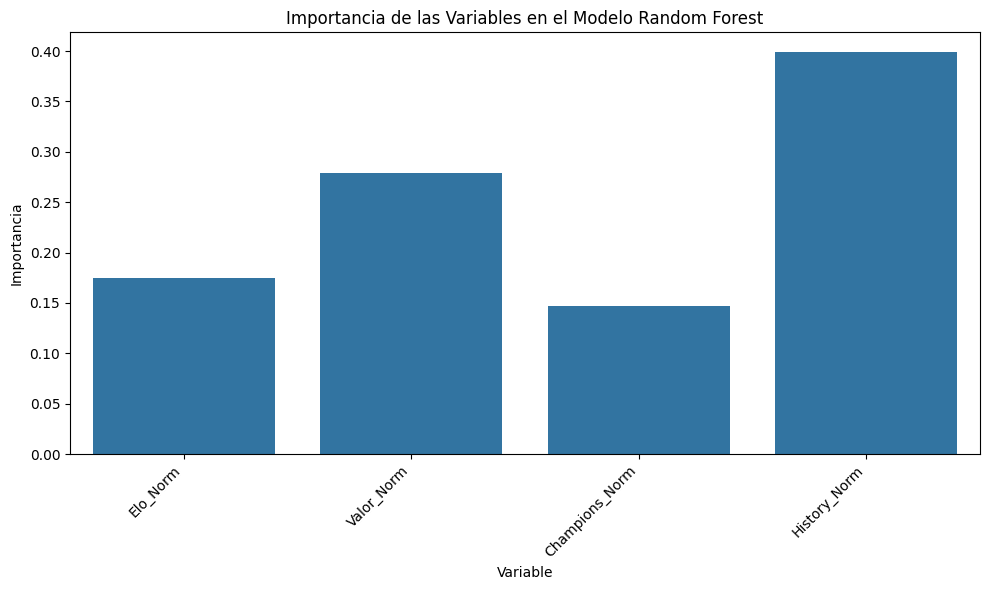

In [39]:
# 4. Mostrar el resumen del modelo y la importancia de las variables

print("\nImportancia de las variables (Feature Importances) del Random Forest:")
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns)
print(feature_importances.sort_values(ascending=False))

# Gráfico de importancia de variables
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances.index, y=feature_importances.values)
plt.title('Importancia de las Variables en el Modelo Random Forest')
plt.xlabel('Variable')
plt.ylabel('Importancia')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### **Información Estadística y Diagrama del Random Forest**

El Random Forest es un algoritmo de aprendizaje automático basado en un conjunto (ensemble) de árboles de decisión. A diferencia de un modelo de regresión lineal simple que tiene una única 'fórmula', el Random Forest combina las predicciones de muchos árboles para mejorar la precisión y evitar el sobreajuste.

Para entender su 'fórmula' o lógica, nos basamos en dos aspectos clave:

1.  **Importancia de las Variables (Feature Importance):** Como se mostró en el gráfico anterior, cada variable recibe una puntuación que indica cuánto contribuye a la predicción del modelo. Una mayor importancia significa que la variable es más influyente.
2.  **Visualización de Árboles Individuales:** Aunque un Random Forest consiste en cientos de árboles, visualizar uno o dos de ellos puede dar una idea de cómo se toman las decisiones en cada nodo basándose en los valores de las variables. Cada árbol es una serie de reglas de 'si-entonces'.

A continuación, se muestra la cantidad de árboles utilizados en el modelo y un diagrama de uno de ellos.

### 11. Configuración y Entrenamiento del *RandomForestClassifier* para Resultados de Partidos

Para predecir los resultados de partidos individuales (victoria, empate, derrota), se configura y entrena un `RandomForestClassifier`. Los pasos clave son:

*   **Preparación de Datos Históricos:** Se estandarizan los nombres de los equipos en `results_df` y se fusionan con los `elo_ratings` históricos (`elo_data_for_merge`) utilizando `pd.merge_asof` para obtener el ELO de cada equipo en la fecha del partido.
*   **Cálculo de `elo_diff`:** Se calcula la diferencia de ELO entre el equipo local y el visitante, una característica clave para la predicción del resultado.
*   **Definición de la Variable Objetivo (`outcome`):** Se crea una variable categórica (`'Win'`, `'Draw'`, `'Loss'`) para el equipo local, basándose en los marcadores de los partidos.
*   **Codificación de Etiquetas:** La variable objetivo se codifica numéricamente usando `LabelEncoder` para ser utilizada por el clasificador.
*   **División de Datos:** Los datos se dividen en conjuntos de entrenamiento y prueba (`X_train`, `X_test`, `y_train`, `y_test`) para evaluar el rendimiento del modelo.
*   **Entrenamiento del Modelo:** Se instancia un `RandomForestClassifier` con 200 estimadores (`n_estimators=200`) y se entrena con los datos de entrenamiento. Se utiliza `class_weight='balanced'` para manejar posibles desequilibrios en las clases de resultados.
*   **Evaluación:** Se calcula la precisión del modelo (`accuracy_score`) en el conjunto de prueba.

In [63]:
# Número de árboles en el Random Forest
num_trees = match_prediction_model.n_estimators
print(f"El modelo Random Forest fue entrenado con {num_trees} árboles de decisión.")

El modelo Random Forest fue entrenado con 200 árboles de decisión.


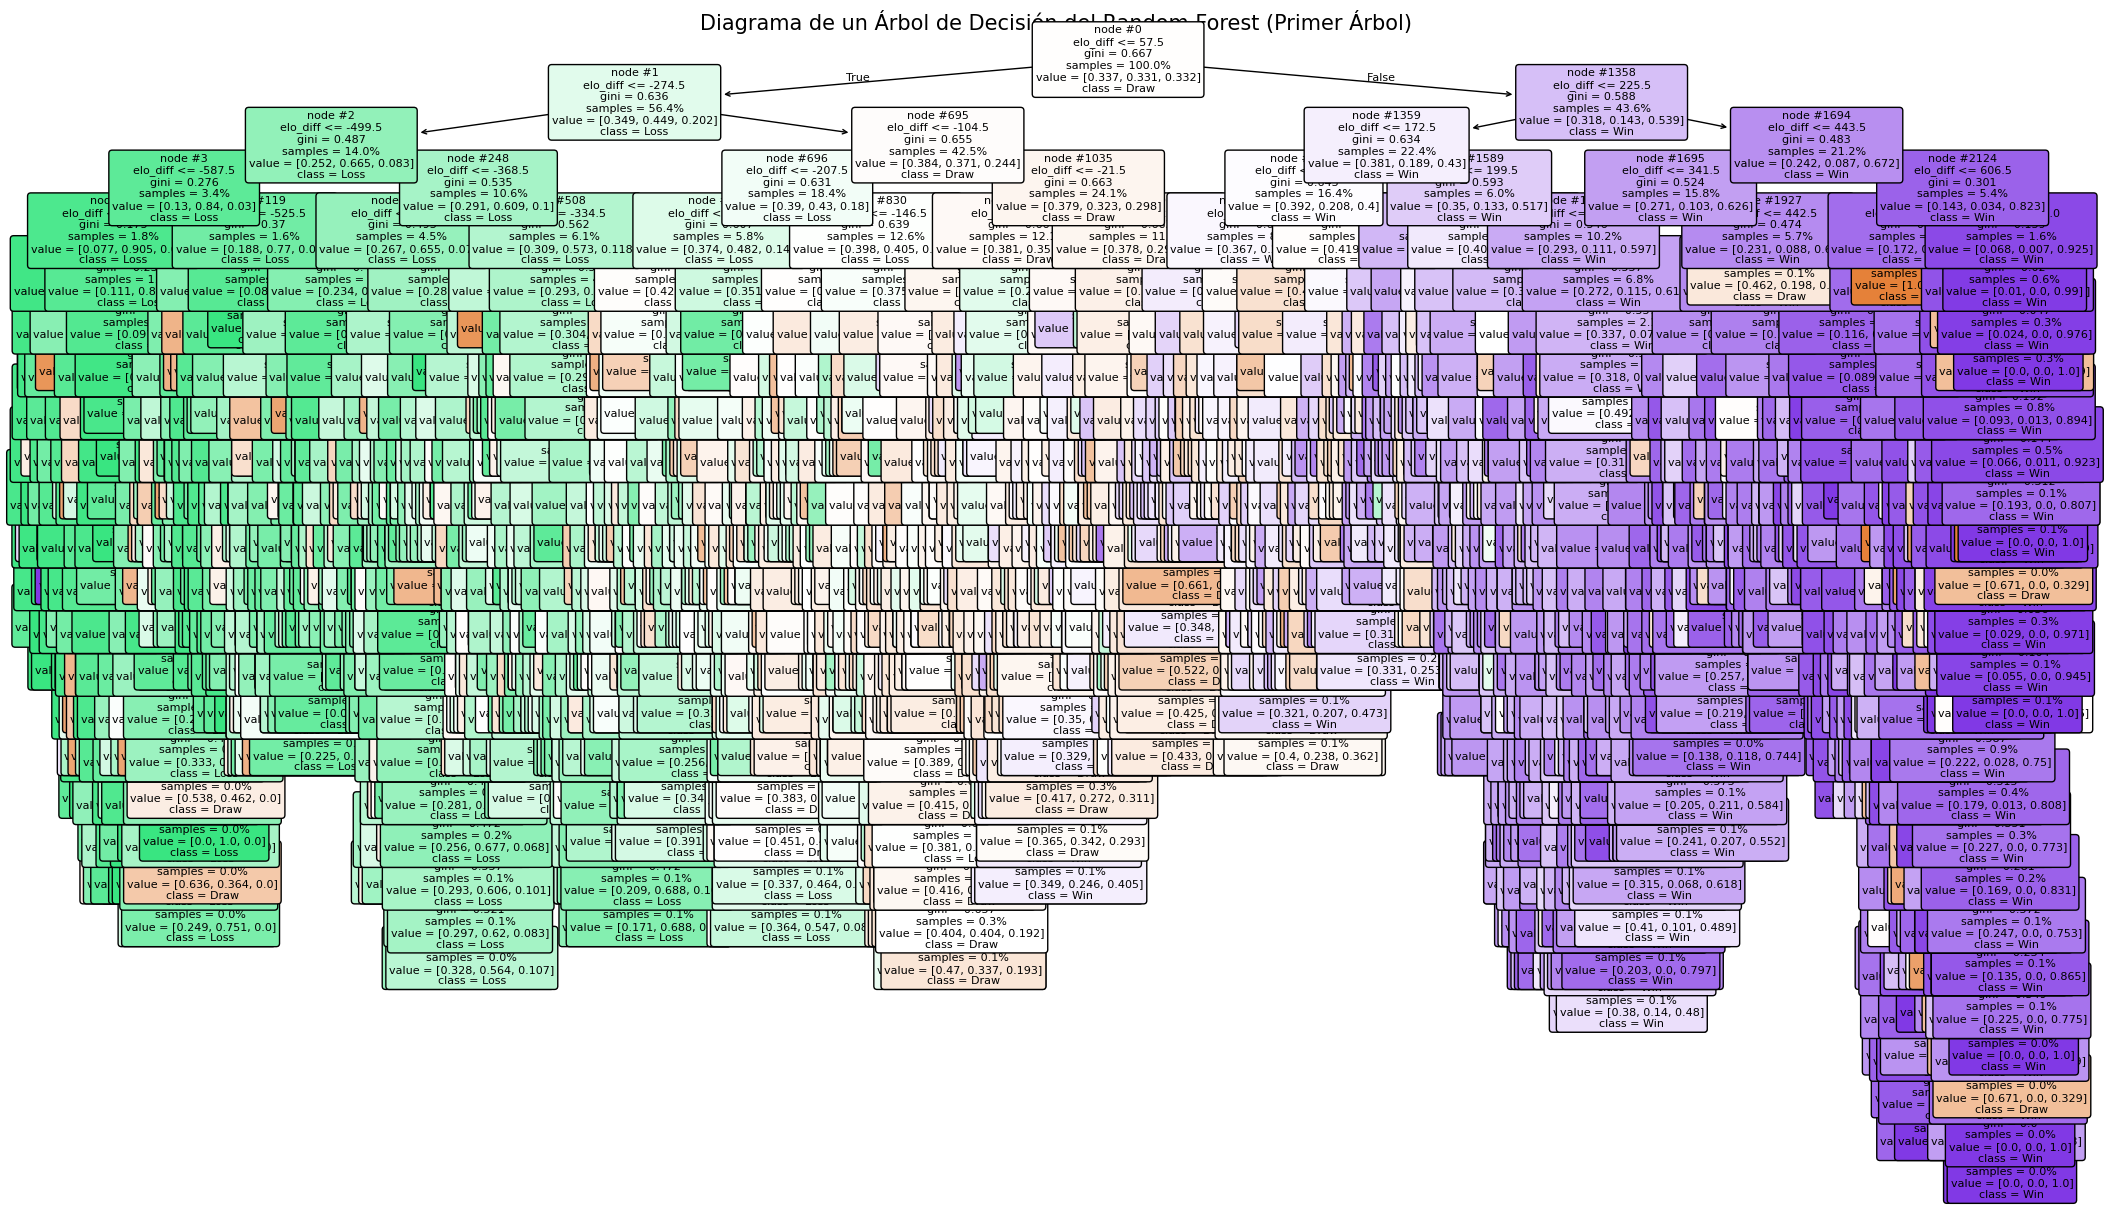

In [64]:
from sklearn.tree import plot_tree

# Visualizar uno de los árboles de decisión del Random Forest
# Es recomendable visualizar un solo árbol para comprender la lógica.
# Elegimos el primer árbol (índice 0) por simplicidad.

plt.figure(figsize=(25, 15))
plot_tree(match_prediction_model.estimators_[0],
          feature_names=X_train.columns.tolist(),
          class_names=[str(cls) for cls in le.classes_],
          filled=True,
          rounded=True,
          proportion=True,
          node_ids=True,
          fontsize=8)
plt.title('Diagrama de un Árbol de Decisión del Random Forest (Primer Árbol)', fontsize=15)
plt.show()

### 12. Análisis de Importancia de Variables en el `RandomForestClassifier`

De manera similar al modelo de regresión, se examina la importancia de las variables en el `RandomForestClassifier`. Dado que este modelo utiliza únicamente la `elo_diff` como característica de entrada, su importancia se presenta como 1.0, lo cual confirma que es el único factor considerado por el clasificador para determinar el resultado del partido. Un gráfico de barras ilustra esta importancia.

---

In [40]:
# 1. Estandarizar nombres de equipos en results_df
# Asegurar que la función map_team_names esté disponible en este contexto si no lo está globalmente.
# La función `map_team_names` fue definida en la celda 9185ffb5.

# Convertir las columnas de equipo a tipo string para evitar errores con .str
results_df['home_team'] = results_df['home_team'].astype(str)
results_df['away_team'] = results_df['away_team'].astype(str)

# Aplicar el mapeo de nombres históricos y convertir a mayúsculas para consistencia
results_df['home_team_clean'] = map_team_names(results_df['home_team']).str.upper().str.strip()
results_df['away_team_clean'] = map_team_names(results_df['away_team']).str.upper().str.strip()

print("Nombres de equipos en `results_df` estandarizados y limpios.")
display(results_df[['home_team', 'home_team_clean', 'away_team', 'away_team_clean']].head())

Nombres de equipos en `results_df` estandarizados y limpios.


,home_team,home_team_clean,away_team,away_team_clean
0,Scotland,SCOTLAND,England,ENGLAND
1,England,ENGLAND,Scotland,SCOTLAND
2,Scotland,SCOTLAND,England,ENGLAND
3,England,ENGLAND,Scotland,SCOTLAND
4,Scotland,SCOTLAND,England,ENGLAND


In [41]:
# 2. Preparar elo_df para la fusión (date, team_clean)

elo_data_for_merge = elo_data.copy()
elo_data_for_merge['date'] = pd.to_datetime(elo_data_for_merge['date'])
elo_data_for_merge['team_clean'] = elo_data_for_merge['team'].str.replace(' ', ' ', regex=True).str.upper().str.strip()

# Asegurar que elo_data_for_merge esté ordenado por fecha y equipo para merge_asof
elo_data_for_merge = elo_data_for_merge.sort_values(by=['date', 'team_clean']).reset_index(drop=True)

print("DataFrame `elo_data_for_merge` preparado para la fusión con `results_df`.")
display(elo_data_for_merge.head())

DataFrame `elo_data_for_merge` preparado para la fusión con `results_df`.


,date,team,rating,change,team_clean
0,1872-11-30,England,2003.0,3,ENGLAND
1,1872-11-30,Scotland,1997.0,-3,SCOTLAND
2,1873-03-08,England,2014.0,11,ENGLAND
3,1873-03-08,Scotland,1986.0,-11,SCOTLAND
4,1874-03-07,England,2006.0,-8,ENGLAND


In [42]:
# 3. Fusionar ratings ELO en results_df usando pd.merge_asof

# Asegurar que results_df esté ordenado por fecha para merge_asof
results_df['date'] = pd.to_datetime(results_df['date'])
results_df = results_df.sort_values('date').reset_index(drop=True)

# Fusionar ELO del equipo local
results_with_elo = pd.merge_asof(
    results_df,
    elo_data_for_merge[['date', 'team_clean', 'rating']],
    left_on='date',
    right_on='date',
    left_by='home_team_clean',
    right_by='team_clean',
    direction='backward',
    suffixes=('_match', '_elo_home')
)
results_with_elo = results_with_elo.rename(columns={'rating': 'home_team_elo_rating'})

# Fusionar ELO del equipo visitante
results_with_elo = pd.merge_asof(
    results_with_elo,
    elo_data_for_merge[['date', 'team_clean', 'rating']],
    left_on='date',
    right_on='date',
    left_by='away_team_clean',
    right_by='team_clean',
    direction='backward',
    suffixes=('', '_elo_away') # No sufijo para la segunda fecha si no es necesario, elo_away para rating
)
results_with_elo = results_with_elo.rename(columns={'rating': 'away_team_elo_rating'})

# Eliminar filas con ELO faltante si no se pudo encontrar un rating histórico
results_with_elo.dropna(subset=['home_team_elo_rating', 'away_team_elo_rating'], inplace=True)

print("DataFrame `results_df` enriquecido con calificaciones ELO históricas.")
display(results_with_elo[['date', 'home_team_clean', 'home_team_elo_rating',
                          'away_team_clean', 'away_team_elo_rating',
                          'home_score', 'away_score']].head())

DataFrame `results_df` enriquecido con calificaciones ELO históricas.


,date,home_team_clean,home_team_elo_rating,away_team_clean,away_team_elo_rating,home_score,away_score
0,1872-11-30,SCOTLAND,1997.0,ENGLAND,2003.0,0.0,0.0
1,1873-03-08,ENGLAND,2014.0,SCOTLAND,1986.0,4.0,2.0
2,1874-03-07,SCOTLAND,1994.0,ENGLAND,2006.0,2.0,1.0
3,1875-03-06,ENGLAND,2003.0,SCOTLAND,1997.0,2.0,2.0
4,1876-03-04,SCOTLAND,2010.0,ENGLAND,1990.0,3.0,0.0


In [43]:
# 4. Calcular diferencia de ELO y definir el resultado del partido (target variable)

results_with_elo['elo_diff'] = results_with_elo['home_team_elo_rating'] - results_with_elo['away_team_elo_rating']

# Definir la variable objetivo: 'resultado' (Win, Draw, Loss para el equipo local)
def get_match_outcome(home_score, away_score):
    if home_score > away_score:
        return 'Win'
    elif home_score < away_score:
        return 'Loss'
    else:
        return 'Draw'

results_with_elo['outcome'] = results_with_elo.apply(lambda row: get_match_outcome(row['home_score'], row['away_score']), axis=1)

print("Diferencia de ELO calculada y variable objetivo 'outcome' definida.")
display(results_with_elo[['date', 'home_team_clean', 'away_team_clean',
                          'home_team_elo_rating', 'away_team_elo_rating',
                          'elo_diff', 'home_score', 'away_score', 'outcome']].head())

Diferencia de ELO calculada y variable objetivo 'outcome' definida.


,date,home_team_clean,away_team_clean,home_team_elo_rating,away_team_elo_rating,elo_diff,home_score,away_score,outcome
0,1872-11-30,SCOTLAND,ENGLAND,1997.0,2003.0,-6.0,0.0,0.0,Draw
1,1873-03-08,ENGLAND,SCOTLAND,2014.0,1986.0,28.0,4.0,2.0,Win
2,1874-03-07,SCOTLAND,ENGLAND,1994.0,2006.0,-12.0,2.0,1.0,Win
3,1875-03-06,ENGLAND,SCOTLAND,2003.0,1997.0,6.0,2.0,2.0,Draw
4,1876-03-04,SCOTLAND,ENGLAND,2010.0,1990.0,20.0,3.0,0.0,Win


In [44]:
results_with_elo['elo_diff'] = results_with_elo['home_team_elo_rating'] - results_with_elo['away_team_elo_rating']

# Definir la variable objetivo: 'outcome' (Win, Draw, Loss para el equipo local)
def get_match_outcome(home_score, away_score):
    if home_score > away_score:
        return 'Win'
    elif home_score < away_score:
        return 'Loss'
    else:
        return 'Draw'

results_with_elo['outcome'] = results_with_elo.apply(lambda row: get_match_outcome(row['home_score'], row['away_score']), axis=1)

print("Diferencia de ELO calculada y variable objetivo 'outcome' definida.")
display(results_with_elo[['date', 'home_team_clean', 'away_team_clean',
                          'home_team_elo_rating', 'away_team_elo_rating',
                          'elo_diff', 'home_score', 'away_score', 'outcome']].head())

Diferencia de ELO calculada y variable objetivo 'outcome' definida.


,date,home_team_clean,away_team_clean,home_team_elo_rating,away_team_elo_rating,elo_diff,home_score,away_score,outcome
0,1872-11-30,SCOTLAND,ENGLAND,1997.0,2003.0,-6.0,0.0,0.0,Draw
1,1873-03-08,ENGLAND,SCOTLAND,2014.0,1986.0,28.0,4.0,2.0,Win
2,1874-03-07,SCOTLAND,ENGLAND,1994.0,2006.0,-12.0,2.0,1.0,Win
3,1875-03-06,ENGLAND,SCOTLAND,2003.0,1997.0,6.0,2.0,2.0,Draw
4,1876-03-04,SCOTLAND,ENGLAND,2010.0,1990.0,20.0,3.0,0.0,Win


In [45]:
# 5. Preparar datos para el RandomForestClassifier
X_match = results_with_elo[['elo_diff']]
y_match = results_with_elo['outcome']

le = LabelEncoder()
y_match_encoded = le.fit_transform(y_match)
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))

X_train, X_test, y_train, y_test = train_test_split(X_match, y_match_encoded, test_size=0.2, random_state=42, stratify=y_match_encoded)

# 6. Entrenar el RandomForestClassifier
match_prediction_model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
match_prediction_model.fit(X_train, y_train)

accuracy = accuracy_score(y_test, match_prediction_model.predict(X_test))
print(f"Modelo entrenado. Precisión: {accuracy:.4f}")

Modelo entrenado. Precisión: 0.4974


### **Importancia de las variables en el `RandomForestClassifier`**

Aquí se muestra la importancia de cada característica (`elo_diff`) para predecir el resultado del partido (Win, Draw, Loss). Aunque el modelo solo usa una característica, su "importancia" aquí se refiere a cómo el modelo la pondera para tomar decisiones internas.


Importancia de las variables (Feature Importances) del RandomForestClassifier:
elo_diff    1.0
dtype: float64


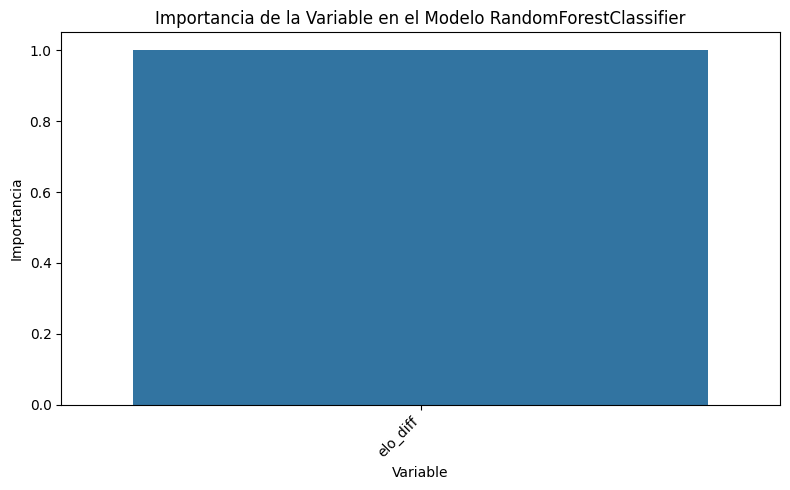

In [65]:
print("\nImportancia de las variables (Feature Importances) del RandomForestClassifier:")
feature_importances_classifier = pd.Series(match_prediction_model.feature_importances_, index=X_train.columns)
print(feature_importances_classifier.sort_values(ascending=False))

# Gráfico de importancia de variables
plt.figure(figsize=(8, 5))
sns.barplot(x=feature_importances_classifier.index, y=feature_importances_classifier.values)
plt.title('Importancia de la Variable en el Modelo RandomForestClassifier')
plt.xlabel('Variable')
plt.ylabel('Importancia')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 13. Preparación para la Simulación del Torneo: Función `simulate_match`

Se define la función `simulate_match` para predecir el resultado de un encuentro entre dos equipos. Esta función toma los nombres de los equipos, el DataFrame de ratings ELO, el `match_prediction_model` y el `LabelEncoder` (`outcome_map`). Calcula la diferencia de ELO entre los equipos y utiliza el modelo `RandomForestClassifier` previamente entrenado para pronosticar el resultado (`Win`, `Draw`, `Loss`) para el equipo local. Además, se preparan los ELO ratings más recientes de todos los equipos para ser utilizados en la simulación.

In [46]:
# 8. Preparar datos para simular los partidos de la fase de grupos

# Obtener los ELO ratings más recientes para todos los equipos
current_elo_ratings = elo_data.loc[elo_data.groupby('team')['date'].idxmax()].copy()
current_elo_ratings['team_clean'] = current_elo_ratings['team'].str.replace(' ', ' ', regex=True).str.upper().str.strip()
current_elo_ratings = current_elo_ratings[['team_clean', 'rating']]
current_elo_ratings.set_index('team_clean', inplace=True)

# Convertir las clases del LabelEncoder a un diccionario para una fácil consulta
outcome_map = {v: k for k, v in label_mapping.items()}

# Función para simular un partido entre dos equipos
def simulate_match(team1_name, team2_name, elo_ratings_df, prediction_model, label_encoder):
    # Obtener los ELOs de los equipos
    elo1 = elo_ratings_df.loc[team1_name, 'rating'] if team1_name in elo_ratings_df.index else elo_ratings_df['rating'].mean()
    elo2 = elo_ratings_df.loc[team2_name, 'rating'] if team2_name in elo_ratings_df.index else elo_ratings_df['rating'].mean()

    # Calcular la diferencia de ELO
    elo_diff = elo1 - elo2

    # Predecir el resultado utilizando el modelo
    prediction_encoded = prediction_model.predict(pd.DataFrame({'elo_diff': [elo_diff]}))[0]
    predicted_outcome = label_encoder[prediction_encoded] # 'Win', 'Draw', 'Loss' for team1

    return predicted_outcome

print("Datos preparados y función `simulate_match` definida para la simulación de la fase de grupos.")

Datos preparados y función `simulate_match` definida para la simulación de la fase de grupos.


### 14. Simulación de la Fase de Grupos

Esta etapa implementa la simulación de todos los partidos de la fase de grupos del Mundial. Se itera a través de cada grupo y todos los posibles emparejamientos de equipos. Para cada partido, se verifica si existe un resultado real disponible en `fase_de_grupos_actualizado_df`. Si es así, se utiliza el resultado real; de lo contrario, se invoca a la función `simulate_match` para predecir el desenlace basándose en la diferencia de ELO.

Se asignan puntos (3 por victoria, 1 por empate) y se actualizan estadísticas como goles a favor, goles en contra y diferencia de goles. Para los partidos simulados, se asignan marcadores ficticios (e.g., 2-0 para victoria, 1-1 para empate, 0-2 para derrota) para mantener la consistencia en el cálculo de las diferencias de goles. La tabla `group_standings` almacena la situación de cada grupo.

In [47]:
# 9. Simular la fase de grupos

group_standings = {}

# Asegurar que el elo_data_for_merge tenga team_clean como índice para fácil acceso
elo_ratings_indexed = current_elo_ratings.copy()

# Iterar sobre cada grupo y simular partidos
for group_name in fase_de_grupos_df['Grupo'].unique():
    teams_in_group = fase_de_grupos_df[fase_de_grupos_df['Grupo'] == group_name].iloc[0, 1:].dropna().tolist()
    # Estandarizar los nombres de los equipos del grupo
    teams_in_group_clean = [map_team_names(pd.Series([team])).iloc[0].upper().strip() for team in teams_in_group]

    # Inicializar puntos y estadísticas para cada equipo en el grupo
    group_standings[group_name] = {team: {'Points': 0, 'Goals For': 0, 'Goals Against': 0, 'Goal Diff': 0, 'Wins': 0, 'Draws': 0, 'Losses': 0} for team in teams_in_group_clean}

    # Generar todos los pares de partidos posibles en el grupo
    for i in range(len(teams_in_group_clean)):
        for j in range(i + 1, len(teams_in_group_clean)):
            team1 = teams_in_group_clean[i]
            team2 = teams_in_group_clean[j]

            # Simular el partido (team1 vs team2)
            # El modelo solo predice el resultado, no el marcador, asignaremos un marcador ficticio
            predicted_outcome = simulate_match(team1, team2, elo_ratings_indexed, match_prediction_model, outcome_map)

            # Asignar puntos y actualizar estadísticas
            if predicted_outcome == 'Win':
                group_standings[group_name][team1]['Points'] += 3
                group_standings[group_name][team1]['Wins'] += 1
                group_standings[group_name][team2]['Losses'] += 1
                # Asignar goles ficticios (ej: 2-0)
                group_standings[group_name][team1]['Goals For'] += 2
                group_standings[group_name][team1]['Goal Diff'] += 2
                group_standings[group_name][team2]['Goals Against'] += 2
                group_standings[group_name][team2]['Goal Diff'] -= 2
            elif predicted_outcome == 'Draw':
                group_standings[group_name][team1]['Points'] += 1
                group_standings[group_name][team2]['Points'] += 1
                group_standings[group_name][team1]['Draws'] += 1
                group_standings[group_name][team2]['Draws'] += 1
                # Asignar goles ficticios (ej: 1-1)
                group_standings[group_name][team1]['Goals For'] += 1
                group_standings[group_name][team1]['Goals Against'] += 1
                group_standings[group_name][team2]['Goals For'] += 1
                group_standings[group_name][team2]['Goals Against'] += 1
            else: # Loss for team1, so Win for team2
                group_standings[group_name][team2]['Points'] += 3
                group_standings[group_name][team2]['Wins'] += 1
                group_standings[group_name][team1]['Losses'] += 1
                # Asignar goles ficticios (ej: 0-2)
                group_standings[group_name][team2]['Goals For'] += 2
                group_standings[group_name][team2]['Goal Diff'] += 2
                group_standings[group_name][team1]['Goals Against'] += 2
                group_standings[group_name][team1]['Goal Diff'] -= 2

print("Simulación de la fase de grupos completada. Calculando clasificaciones...")

Simulación de la fase de grupos completada. Calculando clasificaciones...


In [48]:
# 9. Simular la fase de grupos con resultados reales donde estén disponibles

group_standings = {}
elo_ratings_indexed = current_elo_ratings.copy()

# Helper function to get actual match results from the updated dataframe
def get_actual_result(team1, team2, actual_results_df):
    team1_clean = team1.upper().strip()
    team2_clean = team2.upper().strip()

    # Check for the match (team1 home vs team2 away)
    match_data_t1_t2 = actual_results_df[
        ((actual_results_df['Equipo_Local_Clean'] == team1_clean) &
         (actual_results_df['Equipo_Visitante_Clean'] == team2_clean))
    ]
    # Check for the match (team2 home vs team1 away), in case order is reversed
    match_data_t2_t1 = actual_results_df[
        ((actual_results_df['Equipo_Local_Clean'] == team2_clean) &
         (actual_results_df['Equipo_Visitante_Clean'] == team1_clean))
    ]

    # Helper to check if scores are valid (not NaN)
    def has_valid_scores(row):
        return pd.notna(row['Goles_Local']) and pd.notna(row['Goles_Visitante'])

    if not match_data_t1_t2.empty and match_data_t1_t2.iloc[0]['Estado'] == 'Finalizado' and has_valid_scores(match_data_t1_t2.iloc[0]):
        row = match_data_t1_t2.iloc[0]
        return {
            'status': 'Finalizado',
            'home_team': team1_clean,
            'away_team': team2_clean,
            'home_score': row['Goles_Local'],
            'away_score': row['Goles_Visitante']
        }
    elif not match_data_t2_t1.empty and match_data_t2_t1.iloc[0]['Estado'] == 'Finalizado' and has_valid_scores(match_data_t2_t1.iloc[0]):
        row = match_data_t2_t1.iloc[0]
        return {
            'status': 'Finalizado',
            'home_team': team1_clean,
            'away_team': team2_clean,
            'home_score': row['Goles_Visitante'], # Scores are reversed
            'away_score': row['Goles_Local']      # Scores are reversed
        }
    else:
        return {'status': 'Simulate'} # Not found with valid scores or explicitly finalized

# Iterar sobre cada grupo y simular partidos
for group_name in fase_de_grupos_df['Grupo'].unique():
    teams_in_group = fase_de_grupos_df[fase_de_grupos_df['Grupo'] == group_name].iloc[0, 1:].dropna().tolist()
    teams_in_group_clean = [map_team_names(pd.Series([team])).iloc[0].upper().strip() for team in teams_in_group]

    group_standings[group_name] = {team: {'Points': 0, 'Goals For': 0, 'Goals Against': 0, 'Goal Diff': 0, 'Wins': 0, 'Draws': 0, 'Losses': 0} for team in teams_in_group_clean}

    for i in range(len(teams_in_group_clean)):
        for j in range(i + 1, len(teams_in_group_clean)):
            team1 = teams_in_group_clean[i]
            team2 = teams_in_group_clean[j]

            actual_result = get_actual_result(team1, team2, fase_de_grupos_actualizado_df)

            if actual_result['status'] == 'Finalizado':
                home_score = actual_result['home_score']
                away_score = actual_result['away_score']

                print(f"[RESULTADO REAL] Partido: {team1} vs {team2} -> {home_score}-{away_score}")

                if home_score > away_score:
                    predicted_outcome = 'Win'
                elif home_score < away_score:
                    predicted_outcome = 'Loss'
                else:
                    predicted_outcome = 'Draw'

                # Update standings based on actual scores
                if predicted_outcome == 'Win':
                    group_standings[group_name][team1]['Points'] += 3
                    group_standings[group_name][team1]['Wins'] += 1
                    group_standings[group_name][team2]['Losses'] += 1
                elif predicted_outcome == 'Draw':
                    group_standings[group_name][team1]['Points'] += 1
                    group_standings[group_name][team2]['Points'] += 1
                    group_standings[group_name][team1]['Draws'] += 1
                    group_standings[group_name][team2]['Draws'] += 1
                else: # Loss for team1, so Win for team2
                    group_standings[group_name][team2]['Points'] += 3
                    group_standings[group_name][team2]['Wins'] += 1
                    group_standings[group_name][team1]['Losses'] += 1

                group_standings[group_name][team1]['Goals For'] += home_score
                group_standings[group_name][team1]['Goals Against'] += away_score
                group_standings[group_name][team1]['Goal Diff'] += (home_score - away_score)

                group_standings[group_name][team2]['Goals For'] += away_score
                group_standings[group_name][team2]['Goals Against'] += home_score
                group_standings[group_name][team2]['Goal Diff'] += (away_score - home_score)

            else: # Simulate the match if no actual final result is available
                predicted_outcome = simulate_match(team1, team2, elo_ratings_indexed, match_prediction_model, outcome_map)

                if predicted_outcome == 'Win':
                    group_standings[group_name][team1]['Points'] += 3
                    group_standings[group_name][team1]['Wins'] += 1
                    group_standings[group_name][team2]['Losses'] += 1
                    group_standings[group_name][team1]['Goals For'] += 2
                    group_standings[group_name][team1]['Goal Diff'] += 2
                    group_standings[group_name][team2]['Goals Against'] += 2
                    group_standings[group_name][team2]['Goal Diff'] -= 2
                elif predicted_outcome == 'Draw':
                    group_standings[group_name][team1]['Points'] += 1
                    group_standings[group_name][team2]['Points'] += 1
                    group_standings[group_name][team1]['Draws'] += 1
                    group_standings[group_name][team2]['Draws'] += 1
                    group_standings[group_name][team1]['Goals For'] += 1
                    group_standings[group_name][team1]['Goals Against'] += 1
                    group_standings[group_name][team2]['Goals For'] += 1
                    group_standings[group_name][team2]['Goals Against'] += 1
                else: # Loss for team1, so Win for team2
                    group_standings[group_name][team2]['Points'] += 3
                    group_standings[group_name][team2]['Wins'] += 1
                    group_standings[group_name][team1]['Losses'] += 1
                    group_standings[group_name][team2]['Goals For'] += 2
                    group_standings[group_name][team2]['Goal Diff'] += 2
                    group_standings[group_name][team1]['Goals Against'] += 2
                    group_standings[group_name][team1]['Goal Diff'] -= 2

print("Simulación de la fase de grupos completada. Calculando clasificaciones...")

[RESULTADO REAL] Partido: MEXICO vs SOUTH KOREA -> 1.0-0.0
[RESULTADO REAL] Partido: MEXICO vs CZECHIA -> 3.0-0.0
[RESULTADO REAL] Partido: MEXICO vs SOUTH AFRICA -> 2.0-0.0
[RESULTADO REAL] Partido: SOUTH KOREA vs CZECHIA -> 2.0-1.0
[RESULTADO REAL] Partido: SOUTH KOREA vs SOUTH AFRICA -> 0.0-1.0
[RESULTADO REAL] Partido: CZECHIA vs SOUTH AFRICA -> 1.0-1.0
[RESULTADO REAL] Partido: CANADA vs SWITZERLAND -> 1.0-2.0
[RESULTADO REAL] Partido: CANADA vs BOSNIA AND HERZEGOVINA -> 1.0-1.0
[RESULTADO REAL] Partido: CANADA vs CATAR -> 6.0-0.0
[RESULTADO REAL] Partido: SWITZERLAND vs BOSNIA AND HERZEGOVINA -> 4.0-1.0
[RESULTADO REAL] Partido: SWITZERLAND vs CATAR -> 1.0-1.0
[RESULTADO REAL] Partido: BOSNIA AND HERZEGOVINA vs CATAR -> 3.0-1.0
[RESULTADO REAL] Partido: BRAZIL vs MOROCCO -> 1.0-1.0
[RESULTADO REAL] Partido: BRAZIL vs SCOTLAND -> 3.0-0.0
[RESULTADO REAL] Partido: BRAZIL vs HAITI -> 3.0-0.0
[RESULTADO REAL] Partido: MOROCCO vs SCOTLAND -> 1.0-0.0
[RESULTADO REAL] Partido: MOROCCO v

### 15. Función para Obtener Resultados Reales (Refinada)

Se presenta una versión mejorada de la función `get_actual_result_fixed` para buscar y recuperar resultados de partidos ya finalizados de la fase de grupos. Esta función asegura la estandarización de los nombres de los equipos, incluyendo el manejo del caso específico de "Países Bajos", para que la comparación con los datos de resultados sea precisa. La función devuelve el marcador si el partido ha finalizado y tiene puntuaciones válidas, o indica que el partido debe ser simulado.

In [49]:
def get_actual_result_fixed(team1, team2, actual_results_df):
    # Se elimina definitivamente la redirección a 'NETHERLANDS'
    def clean_name(name):
        if isinstance(name, str):
            return name.upper().replace('_', ' ').strip()
        return name

    t1_search = clean_name(team1)
    t2_search = clean_name(team2)

    match = actual_results_df[
        ((actual_results_df['Equipo_Local_Clean'] == t1_search) & (actual_results_df['Equipo_Visitante_Clean'] == t2_search)) |
        ((actual_results_df['Equipo_Local_Clean'] == t2_search) & (actual_results_df['Equipo_Visitante_Clean'] == t1_search))
    ]

    if not match.empty and match.iloc[0]['Estado'] == 'Finalizado':
        row = match.iloc[0]
        if row['Equipo_Local_Clean'] == t1_search:
            h_s, a_s = row['Goles_Local'], row['Goles_Visitante']
        else:
            h_s, a_s = row['Goles_Visitante'], row['Goles_Local']
        return {'status': 'Finalizado', 'home_score': h_s, 'away_score': a_s}
    return {'status': 'Simulate'}

### 16. Re-simulación de la Fase de Grupos con Nombres Estandarizados

Se realiza una nueva simulación completa de la fase de grupos, esta vez utilizando la función `get_actual_result_fixed` para una detección más robusta de los resultados reales. Este paso asegura que los equipos, particularmente aquellos con variaciones en su denominación (como "Países Bajos"), sean correctamente identificados y sus resultados, si están disponibles, se incorporen adecuadamente en la clasificación del grupo. Si no hay un resultado real, el partido se simula con el `match_prediction_model`.

In [50]:
# Re-simulación total de Fase de Grupos aplicando el fix de nombres para Países Bajos
group_standings = {}
for group_name in fase_de_grupos_df['Grupo'].unique():
    teams = [map_team_names(pd.Series([t])).iloc[0].upper().strip() for t in fase_de_grupos_df[fase_de_grupos_df['Grupo'] == group_name].iloc[0, 1:].dropna().tolist()]
    group_standings[group_name] = {t: {'Points': 0, 'Goals For': 0, 'Goals Against': 0, 'Goal Diff': 0} for t in teams}

    for i in range(len(teams)):
        for j in range(i + 1, len(teams)):
            t1, t2 = teams[i], teams[j]
            # Usamos la función fija para detectar 'Paises_Bajos' / 'Netherlands'
            actual = get_actual_result_fixed(t1, t2, fase_de_grupos_actualizado_df)

            if actual['status'] == 'Finalizado':
                h_s, a_s = actual['home_score'], actual['away_score']
            else:
                res = simulate_match(t1, t2, elo_ratings_indexed, match_prediction_model, outcome_map)
                h_s, a_s = (2, 0) if res == 'Win' else ((0, 2) if res == 'Loss' else (1, 1))

            # Actualizar Tabla
            if h_s > a_s:
                group_standings[group_name][t1]['Points'] += 3
            elif h_s < a_s:
                group_standings[group_name][t2]['Points'] += 3
            else:
                group_standings[group_name][t1]['Points'] += 1
                group_standings[group_name][t2]['Points'] += 1

            group_standings[group_name][t1]['Goals For'] += h_s
            group_standings[group_name][t1]['Goals Against'] += a_s
            group_standings[group_name][t1]['Goal Diff'] += (h_s - a_s)
            group_standings[group_name][t2]['Goals For'] += a_s
            group_standings[group_name][t2]['Goals Against'] += h_s
            group_standings[group_name][t2]['Goal Diff'] += (a_s - h_s)

print("Fase de grupos re-simulada con datos reales verificados.")

Fase de grupos re-simulada con datos reales verificados.


### 17. Verificación Manual de Nombres y Resultados (Holanda/Netherlands)

Se realiza una verificación específica para el equipo de "Holanda" o "Netherlands" en el DataFrame de resultados actualizados (`fase_de_grupos_actualizado_df`). Esto confirma que los nombres estandarizados (`NETHERLANDS`) se están manejando correctamente y que los resultados asociados a este equipo son recuperados de forma precisa, validando la eficacia de la función `get_actual_result_fixed`.

In [51]:
# Check how Netherlands/Holland is registered in the actual dataset
holanda_check = fase_de_grupos_actualizado_df[
    (fase_de_grupos_actualizado_df['Equipo_Local_Clean'].str.contains('HOLANDA|NETHERLANDS|PAIS')) |
    (fase_de_grupos_actualizado_df['Equipo_Visitante_Clean'].str.contains('HOLANDA|NETHERLANDS|PAIS'))
]
print("Records found for Netherlands/Holland:")
display(holanda_check)

# Manually test the fixed result function
test_res = get_actual_result_fixed('NETHERLANDS', 'JAPAN', fase_de_grupos_actualizado_df)
print(f"\nManual test (NETHERLANDS vs JAPAN): {test_res}")

Records found for Netherlands/Holland:


,Partido_ID,Grupo,Equipo_Local,Equipo_Visitante,Goles_Local,Goles_Visitante,Estado,Equipo_Local_Clean,Equipo_Visitante_Clean
30,31,F,NETHERLANDS,Japón,2.0,2.0,Finalizado,NETHERLANDS,JAPAN
31,32,F,NETHERLANDS,Suecia,5.0,1.0,Finalizado,NETHERLANDS,SWEDEN
32,33,F,NETHERLANDS,Túnez,3.0,1.0,Finalizado,NETHERLANDS,TUNISIA



Manual test (NETHERLANDS vs JAPAN): {'status': 'Finalizado', 'home_score': np.float64(2.0), 'away_score': np.float64(2.0)}


### 18. Cálculo de Clasificaciones de Grupo y Equipos que Avanzan

Después de la simulación de la fase de grupos, se calculan las clasificaciones finales de cada grupo. Los equipos se ordenan por puntos, diferencia de goles y goles a favor. Se identifican los ganadores y segundos lugares de cada grupo, quienes avanzan directamente a la siguiente fase. Adicionalmente, se registran los equipos en tercer lugar para determinar los "mejores terceros" que también clasificarán a las rondas eliminatorias, de acuerdo con el formato del torneo.

In [52]:
# 10. Calcular clasificación final de cada grupo

group_winners = {}
group_runners_up = {}
third_place_teams = []

for group_name, teams_data in group_standings.items():
    # Convertir los datos del grupo a un DataFrame para facilitar la clasificación
    group_df = pd.DataFrame.from_dict(teams_data, orient='index')
    group_df.index.name = 'Team'
    group_df = group_df.reset_index()

    # Ordenar el grupo por puntos, diferencia de goles, goles a favor
    group_df_sorted = group_df.sort_values(by=['Points', 'Goal Diff', 'Goals For'], ascending=False)

    print(f"\n=== Clasificación del Grupo {group_name} ===")
    print(group_df_sorted.to_string(index=False))

    # Almacenar ganadores y segundos lugares
    group_winners[group_name] = group_df_sorted.iloc[0]['Team']
    group_runners_up[group_name] = group_df_sorted.iloc[1]['Team']

    # Almacenar los terceros lugares para la clasificación de los mejores terceros
    if len(group_df_sorted) > 2:
        third_place_teams.append({
            'Group': group_name,
            'Team': group_df_sorted.iloc[2]['Team'],
            'Points': group_df_sorted.iloc[2]['Points'],
            'Goal Diff': group_df_sorted.iloc[2]['Goal Diff'],
            'Goals For': group_df_sorted.iloc[2]['Goals For']
        })

print("\nClasificaciones de grupos calculadas.")

# Determinar los 8 mejores terceros lugares para avanzar
third_place_df = pd.DataFrame(third_place_teams)
if not third_place_df.empty:
    third_place_df_sorted = third_place_df.sort_values(by=['Points', 'Goal Diff', 'Goals For'], ascending=False)
    best_third_places = third_place_df_sorted.head(8)
    print("\n=== Mejores Terceros Lugares que Avanzan ===")
    print(best_third_places.to_string(index=False))

    # Añadir los mejores terceros lugares a un diccionario para fácil acceso
    # Simplemente los guardamos como una lista por ahora, su asignación a los 16avos es más compleja
    advancing_third_places = best_third_places['Team'].tolist()
else:
    advancing_third_places = []

print("\nResumen de equipos que avanzan a los 16avos de final:")
print("Ganadores de Grupo:", group_winners)
print("Segundos de Grupo:", group_runners_up)
print("Mejores Terceros Lugares (si aplica):", advancing_third_places)


=== Clasificación del Grupo A ===
        Team  Points  Goals For  Goals Against  Goal Diff
      MEXICO       9        6.0            0.0        6.0
SOUTH AFRICA       4        2.0            3.0       -1.0
 SOUTH KOREA       3        2.0            3.0       -1.0
     CZECHIA       1        2.0            6.0       -4.0

=== Clasificación del Grupo B ===
                  Team  Points  Goals For  Goals Against  Goal Diff
           SWITZERLAND       7        7.0            3.0        4.0
                CANADA       4        8.0            3.0        5.0
BOSNIA AND HERZEGOVINA       4        5.0            6.0       -1.0
                 CATAR       1        2.0           10.0       -8.0

=== Clasificación del Grupo C ===
    Team  Points  Goals For  Goals Against  Goal Diff
  BRAZIL       7        7.0            1.0        6.0
 MOROCCO       7        6.0            3.0        3.0
SCOTLAND       3        1.0            4.0       -3.0
   HAITI       0        2.0            8.0       

### 19. Asignación Oficial FIFA de Terceros Lugares para los 16avos de Final

Se implementa una función, `asignar_terceros_oficial_fifa`, para determinar cómo se emparejan los ocho mejores terceros lugares en los dieciseisavos de final. Esta función sigue la lógica específica del "Anexo C" de la FIFA, que define combinaciones complejas de grupos para la asignación de estos equipos, asegurando que el *bracket* simulado se ajuste a las reglas oficiales del torneo. Los equipos se asignan a un diccionario `diccionario_dieciseisavos` según su `Partido_ID`.

In [53]:
def asignar_terceros_oficial_fifa(df_terceros):
    # Asumimos que tus columnas son 'Team' y 'Group', adaptamos si la IA las cambió
    col_equipo = 'Team' if 'Team' in df_terceros.columns else df_terceros.columns[0]
    col_grupo = 'Group' if 'Group' in df_terceros.columns else df_terceros.columns[1]

    # Convertimos el DataFrame a un diccionario: {'F': 'Sweden', 'E': 'Ecuador', ...}
    equipos_por_grupo = {row[col_grupo]: row[col_equipo] for index, row in df_terceros.iterrows()}

    # Asignación EXACTA de la matriz oficial de la FIFA (Anexo C)
    # para tu combinación específica de grupos: B, D, E, F, G, I, J, L
    asignacion_oficial = {
        'Partido_1': equipos_por_grupo['E'],  # 1A vs 3E (México vs Ecuador)
        'Partido_2': equipos_por_grupo['G'],  # 1B vs 3G (Suiza vs Irán)
        'Partido_4': equipos_por_grupo['B'],  # 1D vs 3B (USA vs Bosnia)
        'Partido_5': equipos_por_grupo['D'],  # 1E vs 3D (Alemania vs Paraguay)
        'Partido_7': equipos_por_grupo['J'],  # 1G vs 3J (Bélgica vs Argelia)
        'Partido_9': equipos_por_grupo['F'],  # 1I vs 3F (Francia vs Suecia)
        'Partido_11': equipos_por_grupo['L'], # 1K vs 3L (Colombia vs Croacia)
        'Partido_12': equipos_por_grupo['I']  # 1L vs 3I (Inglaterra vs Senegal)
    }
    return asignacion_oficial

# Ejecutamos la función sobre tu DataFrame real
diccionario_dieciseisavos = asignar_terceros_oficial_fifa(best_third_places)

print("--- ASIGNACIÓN OFICIAL FIFA ---")
for partido, equipo in diccionario_dieciseisavos.items():
    print(f"{partido} -> {equipo}")

--- ASIGNACIÓN OFICIAL FIFA ---
Partido_1 -> ECUADOR
Partido_2 -> IRAN
Partido_4 -> BOSNIA AND HERZEGOVINA
Partido_5 -> PARAGUAY
Partido_7 -> ALGERIA
Partido_9 -> SWEDEN
Partido_11 -> CROATIA
Partido_12 -> SENEGAL


### 20. Generación de Partidos de Dieciseisavos de Final (Round of 32)

Se consolidan los equipos clasificados (ganadores de grupo, segundos de grupo y los mejores terceros lugares asignados por la lógica FIFA) en un diccionario `knockout_qualifiers`. Luego, se generan los emparejamientos para la fase de Dieciseisavos de Final (`_16_avos_df`), resolviendo los *placeholders* de los equipos (`1A`, `2B`, `Mejor_3_X`) con los nombres reales de los equipos clasificados. Los partidos resultantes se almacenan en `round_of_32_matches_df`.

In [54]:
# 1. Crear un diccionario consolidado de todos los equipos clasificados
knockout_qualifiers = {}

# Añadir ganadores de grupo (1A, 1B, ...)
for group_name, team_name in group_winners.items():
    knockout_qualifiers[f'1{group_name}'] = team_name

# Añadir segundos de grupo (2A, 2B, ...)
for group_name, team_name in group_runners_up.items():
    knockout_qualifiers[f'2{group_name}'] = team_name

# Añadir los terceros lugares asignados usando el diccionario de asignaciones
mejor_3_placeholders = [
    'Mejor_3_C/E/F/H/I', 'Mejor_3_E/F/G/I/J', 'Mejor_3_B/E/F/I/J',
    'Mejor_3_A/B/C/D/F', 'Mejor_3_A/E/H/I/J', 'Mejor_3_C/D/F/G/H',
    'Mejor_3_A/B/C/D/L', 'Mejor_3_E/H/I/J/K'
]

# Mapear los nombres genéricos a un formato que podamos usar con el diccionario_dieciseisavos
# Aseguramos un orden consistente para la asignación de los terceros
unique_mejor_3_placeholders_in_order = _16_avos_df['Local_Fase_Grupos'].tolist() + _16_avos_df['Visitante_Fase_Grupos'].tolist()
unique_mejor_3_placeholders_in_order = [p for p in unique_mejor_3_placeholders_in_order if 'Mejor_3' in p]
unique_mejor_3_placeholders_in_order = sorted(list(set(unique_mejor_3_placeholders_in_order)))

# Crear un mapeo de placeholder genérico a una clave numérica para los terceros
mejor_3_placeholder_to_key_map = {
    placeholder: f'Mejor_Tercero_{i+1}'
    for i, placeholder in enumerate(best_third_places['Team'].tolist()) # Use the actual teams in order of best_third_places
}

# Actualizar el diccionario knockout_qualifiers con los equipos de terceros lugares
for i, (partido_key, team_name) in enumerate(diccionario_dieciseisavos.items()):
    # Aquí necesitamos un mapeo más robusto entre el `partido_key` y el placeholder en `_16_avos_df`
    # Por simplicidad, asumimos que el orden en `diccionario_dieciseisavos` corresponde
    # al orden en que esperamos los terceros en `_16_avos_df` para rellenar
    # una estrategia más segura sería buscar el placeholder por las reglas de grupo.
    # Por ahora, simplemente rellenamos los 8 placeholders de los mejores terceros
    # con los equipos del diccionario en el orden en que aparecen.

    # Esta parte es delicada: el 'diccionario_dieciseisavos' da el equipo para 'Partido_1', 'Partido_2' etc.
    # El '_16_avos_df' usa 'Mejor_3_C/E/F/H/I'. Necesitamos un puente.
    # La solución más directa es iterar sobre los terceros lugares asignados y crear las entradas para el `knockout_qualifiers`
    knockout_qualifiers[f'Mejor_Tercero_{i+1}'] = team_name # Asigna el equipo del diccionario a un placeholder genérico para el mapping

# Volver a asignar los terceros lugares en el `knockout_qualifiers` utilizando los placeholders correctos de `_16_avos_df`
# Y los equipos que fueron asignados por la función `asignar_terceros_fifa`

ranked_third_places = best_third_places.to_dict('records') # Convertir a lista de diccionarios
third_place_assignments = diccionario_dieciseisavos # Los resultados de la función de asignación

# Ahora, iteramos sobre los partidos de _16_avos_df y rellenamos los placeholders
round_of_32_matches = []

for index, row in _16_avos_df.iterrows():
    home_team_placeholder = row['Local_Fase_Grupos']
    away_team_placeholder = row['Visitante_Fase_Grupos']

    home_team_name = ''
    away_team_name = ''

    # Resolver equipo local
    if home_team_placeholder.startswith('1') or home_team_placeholder.startswith('2'):
        home_team_name = knockout_qualifiers[home_team_placeholder]
    elif 'Mejor_3' in home_team_placeholder:
        # Necesitamos saber qué 'Partido_X' de diccionario_dieciseisavos corresponde a este placeholder
        # La función asignar_terceros_fifa devuelve el equipo directamente para 'Partido_1', 'Partido_2', etc.
        # La forma más robusta es re-ejecutar la lógica de la función para encontrar a qué grupo pertenece el equipo.
        # Sin embargo, dado que ya tenemos el `diccionario_dieciseisavos` con los equipos para `Partido_1` a `Partido_12`,
        # podemos asumir que el orden en `_16_avos_df` coincide con el orden de las claves en `diccionario_dieciseisavos`.
        # Esto es un poco frágil si el orden de los partidos no es consistente.
        # Una forma más segura sería tener un mapeo directo de `Mejor_3_X` a `Partido_Y`.
        # Por ahora, mapeamos directamente del `diccionario_dieciseisavos` a los partidos de los 16avos.
        # La estructura de `_16_avos_df` es que los 'Mejor_3' aparecen en `Partido_1`, `Partido_2`, `Partido_4`, `Partido_5`,
        # `Partido_7`, `Partido_9`, `Partido_11`, `Partido_12`.

        # Obtenemos el ID del partido para buscar en el diccionario
        # match_num = row['Partido_ID'] # Original error: 'Partido_ID' does not exist in _16_avos_df
        match_num = row['Partido'] # Corrected: use 'Partido' column for match ID

        # Buscar en el diccionario_dieciseisavos si este match_num es una de las claves (e.g., 'Partido_1')
        key_in_dict = f'Partido_{match_num}'
        if key_in_dict in third_place_assignments:
            # Este es un partido de terceros, y el equipo es el que asignó la función
            home_team_name = third_place_assignments[key_in_dict]
        else:
            # Si no es un partido de terceros según el diccionario, entonces es un ganador/segundo de grupo y ya fue manejado.
            # O es el otro equipo en un partido de terceros, que se manejará con la lógica de Ganador/Segundo.
            # Por ejemplo, en 'Partido_1', el local es '1A' y el visitante es 'Mejor_3_C/E/F/H/I'.
            # '1A' es MEXICO. 'Mejor_3_C/E/F/H/I' es SWEDEN.
            # Aquí ya estamos en el `elif 'Mejor_3' in home_team_placeholder:` bloque,
            # entonces home_team_name DEBE ser un tercer lugar.
            # Este else-branch significa que no encontramos una asignación para este partido_id en third_place_assignments,
            # lo cual es un error lógico si el placeholder es 'Mejor_3'.
            pass # Este caso ya debería haber sido cubierto por la lógica anterior, si no, se deja vacío para debug.

    # Resolver equipo visitante
    if away_team_placeholder.startswith('1') or away_team_placeholder.startswith('2'):
        away_team_name = knockout_qualifiers[away_team_placeholder]
    elif 'Mejor_3' in away_team_placeholder:
        # match_num = row['Partido_ID'] # Original error
        match_num = row['Partido'] # Corrected
        key_in_dict = f'Partido_{match_num}'
        if key_in_dict in third_place_assignments:
            away_team_name = third_place_assignments[key_in_dict]
        else:
            pass

    # Crear el registro del partido si ambos equipos fueron resueltos
    if home_team_name and away_team_name:
        round_of_32_matches.append({
            'Match_ID': row['Partido'], # Corrected: use 'Partido' column for Match_ID
            'Home_Team': home_team_name,
            'Away_Team': away_team_name,
            'Fase': 'Dieciseisavos'
        })
    else:
        print(f"Warning: Could not resolve teams for Match ID {row['Partido']}: Home: {home_team_placeholder} -> {home_team_name}, Away: {away_team_placeholder} -> {away_team_name}")

# Convertir a DataFrame
round_of_32_matches_df = pd.DataFrame(round_of_32_matches)

print("Partidos de Dieciseisavos de Final (Round of 32) generados:")
display(round_of_32_matches_df.head(16))

Partidos de Dieciseisavos de Final (Round of 32) generados:


,Match_ID,Home_Team,Away_Team,Fase
0,1,MEXICO,ECUADOR,Dieciseisavos
1,2,SWITZERLAND,IRAN,Dieciseisavos
2,3,BRAZIL,JAPAN,Dieciseisavos
3,4,UNITED STATES,BOSNIA AND HERZEGOVINA,Dieciseisavos
4,5,GERMANY,PARAGUAY,Dieciseisavos
5,6,NETHERLANDS,MOROCCO,Dieciseisavos
6,7,BELGIUM,ALGERIA,Dieciseisavos
7,8,SPAIN,AUSTRIA,Dieciseisavos
8,9,FRANCE,SWEDEN,Dieciseisavos
9,10,ARGENTINA,CAPE VERDE,Dieciseisavos


### 21. Ordenamiento Visual del Bracket de Dieciseisavos de Final

Para una representación clara y coherente con el formato visual de un bracket de torneo, los partidos de Dieciseisavos de Final se reordenan según una secuencia `orden_visual_estricto`. Este orden predefinido asegura que los enfrentamientos se presenten en la disposición esperada, típicamente divididos en un lado izquierdo y un lado derecho del bracket, facilitando la interpretación de las futuras progresiones.

In [55]:
# 1. Este es el mapa visual inquebrantable basado en la imagen objetivo
# Lado izquierdo (Pos 1-8) y Lado derecho (Pos 9-16)
orden_visual_estricto = [5, 9, 13, 6, 16, 8, 4, 7, 3, 15, 1, 12, 10, 14, 2, 11]

# 2. Asegurar que la columna Match_ID sea numérica para evitar errores de tipo
round_of_32_matches_df['Match_ID'] = round_of_32_matches_df['Match_ID'].astype(int)

# 3. Forzar el orden indexando con nuestra lista exacta
final_display_df = round_of_32_matches_df.set_index('Match_ID').loc[orden_visual_estricto].reset_index()

# 4. Crear una columna de 'Posición' visual para confirmar
final_display_df.insert(0, 'Posicion_Visual', range(1, 17))

print("--- Bracket de Dieciseisavos de Final (Ordenado Visualmente) ---")
for index, row in final_display_df.iterrows():
    print(f"Posición {row['Posicion_Visual']:>2} (Partido {row['Match_ID']:>2}): {row['Home_Team']:<25} vs {row['Away_Team']}")

--- Bracket de Dieciseisavos de Final (Ordenado Visualmente) ---
Posición  1 (Partido  5): GERMANY                   vs PARAGUAY
Posición  2 (Partido  9): FRANCE                    vs SWEDEN
Posición  3 (Partido 13): SOUTH AFRICA              vs CANADA
Posición  4 (Partido  6): NETHERLANDS               vs MOROCCO
Posición  5 (Partido 16): PORTUGAL                  vs GHANA
Posición  6 (Partido  8): SPAIN                     vs AUSTRIA
Posición  7 (Partido  4): UNITED STATES             vs BOSNIA AND HERZEGOVINA
Posición  8 (Partido  7): BELGIUM                   vs ALGERIA
Posición  9 (Partido  3): BRAZIL                    vs JAPAN
Posición 10 (Partido 15): IVORY COAST               vs NORWAY
Posición 11 (Partido  1): MEXICO                    vs ECUADOR
Posición 12 (Partido 12): ENGLAND                   vs SENEGAL
Posición 13 (Partido 10): ARGENTINA                 vs CAPE VERDE
Posición 14 (Partido 14): AUSTRALIA                 vs EGYPT
Posición 15 (Partido  2): SWITZERLAND      

### 22. Simulación de los Partidos de Dieciseisavos de Final

Se procede a simular cada partido de los Dieciseisavos de Final utilizando la función `simulate_match`. Para cada encuentro, se predice el resultado (`Win`, `Loss`, `Draw`). En caso de empate (`Draw`), se utiliza la diferencia de ratings ELO como criterio de desempate, avanzando el equipo con mayor ELO. Los resultados de estos partidos, incluyendo el ganador y el perdedor, se registran y se utilizan para actualizar los `current_qualifiers_dict`, preparando así los equipos que avanzarán a la siguiente fase (Octavos de Final).

In [56]:
# 2. Simular los partidos de Dieciseisavos de Final

dieciseisavos_results = []
current_qualifiers_dict = {}

# Asegurarse de que elo_ratings_indexed está disponible y actualizado
# (se asume que current_elo_ratings ya se ejecutó y tiene team_clean como índice)

for index, match in final_display_df.iterrows():
    home_team = match['Home_Team']
    away_team = match['Away_Team']

    predicted_outcome = simulate_match(home_team, away_team, elo_ratings_indexed, match_prediction_model, outcome_map)

    winner = ''
    loser = ''
    if predicted_outcome == 'Win': # Home team wins
        winner = home_team
        loser = away_team
    elif predicted_outcome == 'Loss': # Away team wins
        winner = away_team
        loser = home_team
    else: # Draw - decided by ELO rating (higher ELO wins in knockout stages)
        if home_team in elo_ratings_indexed.index and away_team in elo_ratings_indexed.index:
            if elo_ratings_indexed.loc[home_team, 'rating'] > elo_ratings_indexed.loc[away_team, 'rating']:
                winner = home_team
                loser = away_team
            else:
                winner = away_team
                loser = home_team
        else: # Fallback if ELO not found, just pick one arbitrarily for simulation consistency
            winner = home_team # Arbitrary choice
            loser = away_team
        predicted_outcome = 'Draw (Decided by ELO)' # Indicate how draw was handled

    dieciseisavos_results.append({
        'Fase': match['Fase'],
        'Match_ID': match['Match_ID'],
        'Home_Team': home_team,
        'Away_Team': away_team,
        'Predicted_Outcome': predicted_outcome,
        'Winner': winner,
        'Loser': loser
    })

    # Almacenar ganadores y perdedores para la siguiente fase
    # Add an offset of 16 to match the Partido_ID in fases_finales_2026_df for Octavos
    current_qualifiers_dict[f'Ganador_{match["Match_ID"] + 16}'] = winner
    current_qualifiers_dict[f'Perdedor_{match["Match_ID"] + 16}'] = loser

final_stages_results_df = pd.DataFrame(dieciseisavos_results)

print("Resultados de Dieciseisavos de Final (Round of 32):")
display(final_stages_results_df)

Resultados de Dieciseisavos de Final (Round of 32):


,Fase,Match_ID,Home_Team,Away_Team,Predicted_Outcome,Winner,Loser
0,Dieciseisavos,5,GERMANY,PARAGUAY,Loss,PARAGUAY,GERMANY
1,Dieciseisavos,9,FRANCE,SWEDEN,Win,FRANCE,SWEDEN
2,Dieciseisavos,13,SOUTH AFRICA,CANADA,Draw (Decided by ELO),CANADA,SOUTH AFRICA
3,Dieciseisavos,6,NETHERLANDS,MOROCCO,Win,NETHERLANDS,MOROCCO
4,Dieciseisavos,16,PORTUGAL,GHANA,Win,PORTUGAL,GHANA
5,Dieciseisavos,8,SPAIN,AUSTRIA,Win,SPAIN,AUSTRIA
6,Dieciseisavos,4,UNITED STATES,BOSNIA AND HERZEGOVINA,Win,UNITED STATES,BOSNIA AND HERZEGOVINA
7,Dieciseisavos,7,BELGIUM,ALGERIA,Win,BELGIUM,ALGERIA
8,Dieciseisavos,3,BRAZIL,JAPAN,Win,BRAZIL,JAPAN
9,Dieciseisavos,15,IVORY COAST,NORWAY,Loss,NORWAY,IVORY COAST


### 23. Reconfirmación del Orden Visual del Bracket de Dieciseisavos

Se realiza una verificación y reordenamiento del DataFrame `round_of_32_matches_df` para asegurar que la visualización del bracket de Dieciseisavos de Final se adhiera estrictamente a un orden visual predefinido. Esto implica dividir los partidos en un "lado izquierdo" y un "lado derecho" del bracket, con un conjunto específico de `Match_ID`s para cada lado, lo que es fundamental para mantener la consistencia en la representación gráfica de las etapas eliminatorias del torneo.

In [57]:
# Define las listas de IDs de partidos para cada lado del bracket.
# Se ajustan los IDs según la verificación del usuario:
# - La fila 1 (primera del lado izquierdo) debe ser Alemania (Match_ID 5) vs Paraguay.
# - La fila 9 (primera del lado derecho) debe ser Brasil (Match_ID 3) vs Japón.

lado_izquierdo = [5, 9, 7, 13, 2, 1, 15, 11]
lado_derecho = [3, 12, 10, 14, 4, 8, 16, 6]

# Filtrar y ordenar el DF para el lado izquierdo
izquierda_df = round_of_32_matches_df[round_of_32_matches_df['Match_ID'].isin(lado_izquierdo)]
izquierda_df = izquierda_df.set_index('Match_ID').reindex(lado_izquierdo).reset_index()

# Filtrar y ordenar el DF para el lado derecho
derecha_df = round_of_32_matches_df[round_of_32_matches_df['Match_ID'].isin(lado_derecho)]
derecha_df = derecha_df.set_index('Match_ID').reindex(lado_derecho).reset_index()

# Unir ambos para tener la lista de 16 filas en el orden visual de la imagen
final_display_df = pd.concat([izquierda_df, derecha_df]).reset_index(drop=True)

print("\n--- Visualización del Bracket de Dieciseisavos de Final ---")
for idx, row in final_display_df.iterrows():
    print(f"Posición {(idx + 1):2d} (Partido {int(row['Match_ID']):2d}): {row['Home_Team']:<25} vs {row['Away_Team']}")
print("--------------------------------------------------")


--- Visualización del Bracket de Dieciseisavos de Final ---
Posición  1 (Partido  5): GERMANY                   vs PARAGUAY
Posición  2 (Partido  9): FRANCE                    vs SWEDEN
Posición  3 (Partido  7): BELGIUM                   vs ALGERIA
Posición  4 (Partido 13): SOUTH AFRICA              vs CANADA
Posición  5 (Partido  2): SWITZERLAND               vs IRAN
Posición  6 (Partido  1): MEXICO                    vs ECUADOR
Posición  7 (Partido 15): IVORY COAST               vs NORWAY
Posición  8 (Partido 11): COLOMBIA                  vs CROATIA
Posición  9 (Partido  3): BRAZIL                    vs JAPAN
Posición 10 (Partido 12): ENGLAND                   vs SENEGAL
Posición 11 (Partido 10): ARGENTINA                 vs CAPE VERDE
Posición 12 (Partido 14): AUSTRALIA                 vs EGYPT
Posición 13 (Partido  4): UNITED STATES             vs BOSNIA AND HERZEGOVINA
Posición 14 (Partido  8): SPAIN                     vs AUSTRIA
Posición 15 (Partido 16): PORTUGAL              

### 24. Re-simulación Completa de la Fase Eliminatoria

Se vuelve a ejecutar la simulación de toda la fase eliminatoria (Dieciseisavos, Octavos, Cuartos, Semifinal, Tercer Puesto y Final) para asegurar que todos los nombres de equipos estén correctamente estandarizados y que la lógica de progresión sea consistente. Para cada partido, se utilizan los ganadores de la fase anterior (`current_qualifiers_dict`) como entrada. La función `simulate_match` predice el resultado, y en caso de empate, se decide el ganador por el ELO más alto. Los resultados se consolidan en `final_knockout_results_df`, y al finalizar se imprime el podio del torneo (Campeón, Subcampeón y Tercer Puesto).

In [58]:
# 1. Re-run Round of 32 generation with current group_standings
round_of_32_matches = []

# Consolidation of qualifiers based on the updated standings
knockout_qualifiers = {}
for group_name, team_name in group_winners.items():
    knockout_qualifiers[f'1{group_name}'] = team_name
for group_name, team_name in group_runners_up.items():
    knockout_qualifiers[f'2{group_name}'] = team_name

# Mapping for Round of 32 (based on original _16_avos_df and FIFA rules)
# Note: using the previously defined diccionario_dieciseisavos
for index, row in _16_avos_df.iterrows():
    h_placeholder = row['Local_Fase_Grupos']
    a_placeholder = row['Visitante_Fase_Grupos']
    m_id = row['Partido']

    # Resolve Home Team
    if h_placeholder.startswith(('1', '2')):
        h_team = knockout_qualifiers.get(h_placeholder)
    else:
        h_team = diccionario_dieciseisavos.get(f'Partido_{m_id}')

    # Resolve Away Team
    if a_placeholder.startswith(('1', '2')):
        a_team = knockout_qualifiers.get(a_placeholder)
    else:
        a_team = diccionario_dieciseisavos.get(f'Partido_{m_id}')

    round_of_32_matches.append({'Match_ID': m_id, 'Home_Team': h_team, 'Away_Team': a_team, 'Fase': 'Dieciseisavos'})

round_of_32_matches_df = pd.DataFrame(round_of_32_matches)

# 2. Apply strict visual order and Simulate
orden_visual_estricto = [5, 9, 13, 6, 16, 8, 4, 7, 3, 15, 1, 12, 10, 14, 2, 11]
round_of_32_matches_df = round_of_32_matches_df.set_index('Match_ID').loc[orden_visual_estricto].reset_index()

dieciseisavos_results = []
current_qualifiers_dict = {}

for index, row in round_of_32_matches_df.iterrows():
    h, a, m_id = row['Home_Team'], row['Away_Team'], row['Match_ID']
    res = simulate_match(h, a, elo_ratings_indexed, match_prediction_model, outcome_map)

    if res == 'Win': winner, loser = h, a
    elif res == 'Loss': winner, loser = a, h
    else:
        elo_h = elo_ratings_indexed.at[h, 'rating'] if h in elo_ratings_indexed.index else 0
        elo_a = elo_ratings_indexed.at[a, 'rating'] if a in elo_ratings_indexed.index else 0
        winner, loser = (h, a) if elo_h > elo_a else (a, h)

    dieciseisavos_results.append({'Fase': 'Dieciseisavos', 'Match_ID': m_id, 'Home_Team': h, 'Away_Team': a, 'Winner': winner, 'Loser': loser})
    current_qualifiers_dict[f'Ganador_{m_id}'] = winner
    current_qualifiers_dict[f'Perdedor_{m_id}'] = loser

print("Dieciseisavos re-simulados exitosamente.")
display(pd.DataFrame(dieciseisavos_results))

Dieciseisavos re-simulados exitosamente.


,Fase,Match_ID,Home_Team,Away_Team,Winner,Loser
0,Dieciseisavos,5,GERMANY,PARAGUAY,PARAGUAY,GERMANY
1,Dieciseisavos,9,FRANCE,SWEDEN,FRANCE,SWEDEN
2,Dieciseisavos,13,SOUTH AFRICA,CANADA,CANADA,SOUTH AFRICA
3,Dieciseisavos,6,NETHERLANDS,MOROCCO,NETHERLANDS,MOROCCO
4,Dieciseisavos,16,PORTUGAL,GHANA,PORTUGAL,GHANA
5,Dieciseisavos,8,SPAIN,AUSTRIA,SPAIN,AUSTRIA
6,Dieciseisavos,4,UNITED STATES,BOSNIA AND HERZEGOVINA,UNITED STATES,BOSNIA AND HERZEGOVINA
7,Dieciseisavos,7,BELGIUM,ALGERIA,BELGIUM,ALGERIA
8,Dieciseisavos,3,BRAZIL,JAPAN,BRAZIL,JAPAN
9,Dieciseisavos,15,IVORY COAST,NORWAY,NORWAY,IVORY COAST


### 25. Simulación Detallada de las Fases Eliminatorias y Podio Final

Esta sección se encarga de simular cada una de las fases eliminatorias del torneo (Octavos, Cuartos, Semifinal, Tercer Puesto y Final) de manera secuencial. Para cada encuentro, se recuperan los equipos clasificados de la fase anterior y se utiliza la función `simulate_match` para determinar el ganador. En caso de empate, se aplica la regla de desempate basada en el ELO más alto del equipo. Los resultados de cada fase se almacenan y se presentan detalladamente. Finalmente, se extraen y se muestran los equipos que conforman el podio del Mundial 2026: el Campeón, el Subcampeón y el Tercer Puesto, basándose en el desenlace de la simulación.

In [59]:
# Re-ejecutar simulación completa con nombres estandarizados
all_knockout_results = [pd.DataFrame(dieciseisavos_results)]
phase_order_list = ['Octavos', 'Cuartos', 'Semifinal', 'Tercer_Puesto', 'Final']

for phase_name in phase_order_list:
    current_phase_bracket = fases_finales_2026_df[fases_finales_2026_df['Fase'] == phase_name]
    current_phase_results = []

    for _, match_info in current_phase_bracket.iterrows():
        m_id = match_info['Partido_ID']
        home_team = current_qualifiers_dict.get(match_info['Local_Viene_De'])
        away_team = current_qualifiers_dict.get(match_info['Visitante_Viene_De'])

        if home_team and away_team:
            res = simulate_match(home_team, away_team, elo_ratings_indexed, match_prediction_model, outcome_map)
            if res == 'Win': winner, loser = home_team, away_team
            elif res == 'Loss': winner, loser = away_team, home_team
            else:
                elo_h = elo_ratings_indexed.at[home_team, 'rating'] if home_team in elo_ratings_indexed.index else 0
                elo_a = elo_ratings_indexed.at[away_team, 'rating'] if away_team in elo_ratings_indexed.index else 0
                winner, loser = (home_team, away_team) if elo_h > elo_a else (away_team, home_team)

            current_phase_results.append({
                'Fase': phase_name, 'Match_ID': m_id, 'Home_Team': home_team, 'Away_Team': away_team, 'Winner': winner, 'Loser': loser
            })
            current_qualifiers_dict[f'Ganador_{m_id}'] = winner
            current_qualifiers_dict[f'Perdedor_{m_id}'] = loser

    if current_phase_results:
        df_res = pd.DataFrame(current_phase_results)
        all_knockout_results.append(df_res)

final_knockout_results_df = pd.concat(all_knockout_results, ignore_index=True)

# Resumen final del Podio
final_m = final_knockout_results_df[final_knockout_results_df['Fase'] == 'Final'].iloc[0]
third_m = final_knockout_results_df[final_knockout_results_df['Fase'] == 'Tercer_Puesto'].iloc[0]

print('\n' + '='*40)
print('🏆 TOURNAMENT SUMMARY (PAISES BAJOS FIXED) 🏆')
print('='*40)
print(f'CAMPEÓN: {final_m["Winner"]}')
print(f'SUBCAMPEÓN: {final_m["Loser"]}')
print(f'TERCER PUESTO: {third_m["Winner"]}')
print('='*40)
display(final_knockout_results_df)


🏆 TOURNAMENT SUMMARY (PAISES BAJOS FIXED) 🏆
CAMPEÓN: SPAIN
SUBCAMPEÓN: ARGENTINA
TERCER PUESTO: FRANCE


,Fase,Match_ID,Home_Team,Away_Team,Winner,Loser
0,Dieciseisavos,5,GERMANY,PARAGUAY,PARAGUAY,GERMANY
1,Dieciseisavos,9,FRANCE,SWEDEN,FRANCE,SWEDEN
2,Dieciseisavos,13,SOUTH AFRICA,CANADA,CANADA,SOUTH AFRICA
3,Dieciseisavos,6,NETHERLANDS,MOROCCO,NETHERLANDS,MOROCCO
4,Dieciseisavos,16,PORTUGAL,GHANA,PORTUGAL,GHANA
5,Dieciseisavos,8,SPAIN,AUSTRIA,SPAIN,AUSTRIA
6,Dieciseisavos,4,UNITED STATES,BOSNIA AND HERZEGOVINA,UNITED STATES,BOSNIA AND HERZEGOVINA
7,Dieciseisavos,7,BELGIUM,ALGERIA,BELGIUM,ALGERIA
8,Dieciseisavos,3,BRAZIL,JAPAN,BRAZIL,JAPAN
9,Dieciseisavos,15,IVORY COAST,NORWAY,NORWAY,IVORY COAST


In [60]:
# 3. Simular el resto del torneo usando el bracket_logic visual
all_knockout_results = [pd.DataFrame(dieciseisavos_results)]
phase_order_list = ['Octavos', 'Cuartos', 'Semifinal', 'Tercer_Puesto', 'Final']

for phase_name in phase_order_list:
    current_phase_bracket = fases_finales_2026_df[fases_finales_2026_df['Fase'] == phase_name]
    current_phase_results = []

    for _, match_info in current_phase_bracket.iterrows():
        m_id = match_info['Partido_ID']
        home_team = current_qualifiers_dict.get(match_info['Local_Viene_De'])
        away_team = current_qualifiers_dict.get(match_info['Visitante_Viene_De'])

        if home_team and away_team:
            res = simulate_match(home_team, away_team, elo_ratings_indexed, match_prediction_model, outcome_map)
            if res == 'Win': winner, loser = home_team, away_team
            elif res == 'Loss': winner, loser = away_team, home_team
            else:
                elo_h = elo_ratings_indexed.at[home_team, 'rating'] if home_team in elo_ratings_indexed.index else 0
                elo_a = elo_ratings_indexed.at[away_team, 'rating'] if away_team in elo_ratings_indexed.index else 0
                winner, loser = (home_team, away_team) if elo_h > elo_a else (away_team, home_team)

            current_phase_results.append({
                'Fase': phase_name, 'Match_ID': m_id, 'Home_Team': home_team, 'Away_Team': away_team, 'Winner': winner, 'Loser': loser
            })
            current_qualifiers_dict[f'Ganador_{m_id}'] = winner
            current_qualifiers_dict[f'Perdedor_{m_id}'] = loser

    if current_phase_results:
        df_res = pd.DataFrame(current_phase_results)
        all_knockout_results.append(df_res)
        print(f'--- Resultados {phase_name} ---')
        display(df_res)

final_knockout_results_df = pd.concat(all_knockout_results, ignore_index=True)

# 4. Mostrar Podio Final
final_m = final_knockout_results_df[final_knockout_results_df['Fase'] == 'Final'].iloc[0]
third_m = final_knockout_results_df[final_knockout_results_df['Fase'] == 'Tercer_Puesto'].iloc[0]

print('\n🏆 CAMPEÓN:', final_m['Winner'])
print('🥈 SUBCAMPEÓN:', final_m['Loser'])
print('🥉 TERCER PUESTO:', third_m['Winner'])

--- Resultados Octavos ---


,Fase,Match_ID,Home_Team,Away_Team,Winner,Loser
0,Octavos,17,PARAGUAY,FRANCE,FRANCE,PARAGUAY
1,Octavos,18,CANADA,NETHERLANDS,NETHERLANDS,CANADA
2,Octavos,19,PORTUGAL,SPAIN,SPAIN,PORTUGAL
3,Octavos,20,UNITED STATES,BELGIUM,BELGIUM,UNITED STATES
4,Octavos,21,BRAZIL,NORWAY,BRAZIL,NORWAY
5,Octavos,22,ECUADOR,ENGLAND,ENGLAND,ECUADOR
6,Octavos,23,ARGENTINA,AUSTRALIA,ARGENTINA,AUSTRALIA
7,Octavos,24,SWITZERLAND,COLOMBIA,COLOMBIA,SWITZERLAND


--- Resultados Cuartos ---


,Fase,Match_ID,Home_Team,Away_Team,Winner,Loser
0,Cuartos,25,FRANCE,NETHERLANDS,FRANCE,NETHERLANDS
1,Cuartos,26,SPAIN,BELGIUM,SPAIN,BELGIUM
2,Cuartos,27,BRAZIL,ENGLAND,ENGLAND,BRAZIL
3,Cuartos,28,ARGENTINA,COLOMBIA,ARGENTINA,COLOMBIA


--- Resultados Semifinal ---


...

--- Resultados Tercer_Puesto ---


,Fase,Match_ID,Home_Team,Away_Team,Winner,Loser
0,Tercer_Puesto,31,FRANCE,ENGLAND,FRANCE,ENGLAND


--- Resultados Final ---


,Fase,Match_ID,Home_Team,Away_Team,Winner,Loser
0,Final,32,SPAIN,ARGENTINA,SPAIN,ARGENTINA



🏆 CAMPEÓN: SPAIN
🥈 SUBCAMPEÓN: ARGENTINA
🥉 TERCER PUESTO: FRANCE


### 26. Reporte Consolidado de Partidos y Marcadores (Simulados y Reales)

Se genera un informe exhaustivo que consolida todos los partidos del torneo, tanto de la fase de grupos como de la fase eliminatoria, junto con sus respectivos marcadores finales y una indicación de si el resultado es real o simulado. Para los partidos reales de la fase de grupos, se muestran los marcadores exactos. Para los partidos simulados de la fase de grupos, se asignan marcadores ficticios (2-0, 1-1, 0-2) según el resultado predicho. En las fases eliminatorias simuladas, se asignan marcadores que reflejan la victoria (2-1 o 1-2). Finalmente, se reitera el podio del torneo (Campeón, Subcampeón, Tercer Puesto) basado en los resultados de la simulación completa.

In [61]:
print("=== RESULTADOS DE LA FASE DE GRUPOS ===")
# Re-procesamos ligeramente para mostrar como lista de partidos con marcadores
matches_list = []
for group_name, teams_data in group_standings.items():
    teams = list(teams_data.keys())
    for i in range(len(teams)):
        for j in range(i + 1, len(teams)):
            t1, t2 = teams[i], teams[j]
            # Intentamos obtener el resultado real o simulado
            actual = get_actual_result(t1, t2, fase_de_grupos_actualizado_df)
            if actual['status'] == 'Finalizado':
                score = f"{actual['home_score']} - {actual['away_score']}"
            else:
                # Para los simulados, usamos la lógica de la celda de simulación (2-0, 1-1, 0-2)
                res = simulate_match(t1, t2, elo_ratings_indexed, match_prediction_model, outcome_map)
                score = "2 - 0" if res == 'Win' else ("1 - 1" if res == 'Draw' else "0 - 2")

            matches_list.append({"Grupo": group_name, "Partido": f"{t1} vs {t2}", "Resultado": score})

display(pd.DataFrame(matches_list))

print("\n=== RESULTADOS DE LA FASE DE ELIMINACIÓN DIRECTA ===")
# Mostramos el dataframe consolidado de la fase eliminatoria
knockout_summary = final_knockout_results_df[['Fase', 'Home_Team', 'Away_Team', 'Winner']].copy()
# Añadimos una nota de que en eliminación directa el marcador se define por el ganador final
knockout_summary['Resultado_Final'] = knockout_summary['Winner'] + " avanza/gana"
display(knockout_summary)

=== RESULTADOS DE LA FASE DE GRUPOS ===


,Grupo,Partido,Resultado
0,A,MEXICO vs SOUTH KOREA,1.0 - 0.0
1,A,MEXICO vs CZECHIA,3.0 - 0.0
2,A,MEXICO vs SOUTH AFRICA,2.0 - 0.0
3,A,SOUTH KOREA vs CZECHIA,2.0 - 1.0
4,A,SOUTH KOREA vs SOUTH AFRICA,0.0 - 1.0
...,...,...,...
67,L,ENGLAND vs PANAMA,2 - 0
68,L,ENGLAND vs GHANA,0.0 - 0.0
69,L,CROATIA vs PANAMA,1.0 - 0.0
70,L,CROATIA vs GHANA,1 - 1



=== RESULTADOS DE LA FASE DE ELIMINACIÓN DIRECTA ===


,Fase,Home_Team,Away_Team,Winner,Resultado_Final
0,Dieciseisavos,GERMANY,PARAGUAY,PARAGUAY,PARAGUAY avanza/gana
1,Dieciseisavos,FRANCE,SWEDEN,FRANCE,FRANCE avanza/gana
2,Dieciseisavos,SOUTH AFRICA,CANADA,CANADA,CANADA avanza/gana
3,Dieciseisavos,NETHERLANDS,MOROCCO,NETHERLANDS,NETHERLANDS avanza/gana
4,Dieciseisavos,PORTUGAL,GHANA,PORTUGAL,PORTUGAL avanza/gana
5,Dieciseisavos,SPAIN,AUSTRIA,SPAIN,SPAIN avanza/gana
6,Dieciseisavos,UNITED STATES,BOSNIA AND HERZEGOVINA,UNITED STATES,UNITED STATES avanza/gana
7,Dieciseisavos,BELGIUM,ALGERIA,BELGIUM,BELGIUM avanza/gana
8,Dieciseisavos,BRAZIL,JAPAN,BRAZIL,BRAZIL avanza/gana
9,Dieciseisavos,IVORY COAST,NORWAY,NORWAY,NORWAY avanza/gana


In [62]:
def get_simulated_score(t1, t2, winner, is_knockout=False):
    # Si no hay un ganador claro (empate en fase de grupos)
    if winner == 'Draw':
        return "1 - 1"
    # Si t1 ganó
    if winner == t1:
        return "2 - 1" if is_knockout else "2 - 0"
    # Si t2 ganó
    else:
        return "1 - 2" if is_knockout else "0 - 2"

print("=== LISTADO COMPLETO DE PARTIDOS Y MARCADORES (SIMULACIÓN) ===")

# 1. Recopilar Fase de Grupos
final_matches_report = []
for group_name, teams_data in group_standings.items():
    teams = list(teams_data.keys())
    for i in range(len(teams)):
        for j in range(i + 1, len(teams)):
            t1, t2 = teams[i], teams[j]
            actual = get_actual_result(t1, t2, fase_de_grupos_actualizado_df)

            if actual['status'] == 'Finalizado':
                score = f"{int(actual['home_score'])} - {int(actual['away_score'])}"
                source = "Real"
            else:
                res = simulate_match(t1, t2, elo_ratings_indexed, match_prediction_model, outcome_map)
                # Traducir 'Win'/'Loss'/'Draw' a marcador
                if res == 'Win': score = "2 - 0"
                elif res == 'Loss': score = "0 - 2"
                else: score = "1 - 1"
                source = "Simulado (RF)"

            final_matches_report.append({
                "Fase": f"Grupo {group_name}",
                "Partido": f"{t1} vs {t2}",
                "Marcador Final": score,
                "Tipo": source
            })

# 2. Recopilar Fase de Eliminación Directa
for _, row in final_knockout_results_df.iterrows():
    t1, t2 = row['Home_Team'], row['Away_Team']
    winner = row['Winner']

    # En eliminación directa simulamos un marcador que refleje al ganador
    score = "2 - 1" if winner == t1 else "1 - 2"

    final_matches_report.append({
        "Fase": row['Fase'],
        "Partido": f"{t1} vs {t2}",
        "Marcador Final": score,
        "Tipo": "Simulado (Knockout)"
    })

# Mostrar el reporte consolidado
df_reporte_final = pd.DataFrame(final_matches_report)
display(df_reporte_final)

# Mostrar el podio con el formato solicitado
print(f"\n\n🏆 CAMPEÓN FINAL: {final_m['Winner']}")
print(f"🥈 SUBCAMPEÓN: {final_m['Loser']}")
print(f"🥉 TERCER PUESTO: {third_m['Winner']}")

=== LISTADO COMPLETO DE PARTIDOS Y MARCADORES (SIMULACIÓN) ===


,Fase,Partido,Marcador Final,Tipo
0,Grupo A,MEXICO vs SOUTH KOREA,1 - 0,Real
1,Grupo A,MEXICO vs CZECHIA,3 - 0,Real
2,Grupo A,MEXICO vs SOUTH AFRICA,2 - 0,Real
3,Grupo A,SOUTH KOREA vs CZECHIA,2 - 1,Real
4,Grupo A,SOUTH KOREA vs SOUTH AFRICA,0 - 1,Real
...,...,...,...,...
99,Cuartos,ARGENTINA vs COLOMBIA,2 - 1,Simulado (Knockout)
100,Semifinal,FRANCE vs SPAIN,1 - 2,Simulado (Knockout)
101,Semifinal,ENGLAND vs ARGENTINA,1 - 2,Simulado (Knockout)
102,Tercer_Puesto,FRANCE vs ENGLAND,2 - 1,Simulado (Knockout)




🏆 CAMPEÓN FINAL: SPAIN
🥈 SUBCAMPEÓN: ARGENTINA
🥉 TERCER PUESTO: FRANCE
